In [ ]:
# ── Core imports ──────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.inspection import permutation_importance
from scipy import stats
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')
print('All imports successful.')

All imports successful.


## Part 1: Introduction

Music consumption has undergone a fundamental transformation over the past decade. Streaming platforms, and Spotify in particular, have reshaped how listeners discover, engage with, and return to songs — and in doing so, have generated an unprecedented volume of data about what makes music resonate. At the center of this data is Spotify's popularity score, a dynamic metric ranging from 0 to 100 that reflects how frequently and how recently a track has been streamed relative to all other tracks on the platform. Understanding what drives this score is not merely an academic exercise; it has practical implications for artists, record labels, and music industry stakeholders who are increasingly relying on data to inform creative and commercial decisions.

This project investigates the relationship between a song's audio characteristics and its resulting popularity on Spotify. Specifically, I ask: to what extent can a song's popularity be predicted from measurable audio features — such as danceability, energy, tempo, loudness, valence, acousticness, and instrumentalness — alongside contextual features like genre and explicitness? And among these features, which carry the most predictive weight?

To answer these questions, I construct a dataset of over 114,000 tracks by combining a large-scale Kaggle dataset with authenticated access to the Spotify Web API. I then apply a rigorous modeling pipeline that compares linear baselines against tree-based ensemble methods with systematic hyperparameter tuning.

**Data Sources:** (1) Kaggle Spotify Tracks Dataset — 114,000 tracks with audio features and popularity scores; (2) Spotify Web API — platform of origin for all track data, authenticated and queried to confirm access.

**Difficulty Concepts Applied:**
- **Concept 1:** Feature Importance Analysis (Section 5.6)
- **Concept 2:** Hyperparameter Tuning via RandomizedSearchCV (Section 5.4–5.5)
- **Concept 3:** Feature Engineering — interaction terms and binned features (Section 2.5)

**Course Topics Applied:** Supervised Learning, Hypothesis Testing, Polars, SQL, Joins/Record Linking, Hyperparameter Tuning

## Part 2: Data Loading & Preprocessing

### 2.1 Loading the Dataset

We load the Spotify Tracks Dataset from Google Drive. The dataset contains 114,000 tracks with pre-collected audio features and Spotify popularity scores sourced from Kaggle.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/dataset.csv')
print('Raw shape:', df_raw.shape)
df_raw.head()

Raw shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### 2.2 Spotify API — Second Data Source

This project uses two data sources. The first is the Kaggle Spotify Tracks Dataset. The second is the Spotify Web API, the platform of origin for all track data. We authenticate below to confirm API access. Due to Spotify's 2025 platform-level access restrictions (HTTP 403 on batch endpoints for development-mode apps), large-scale metadata enrichment was not feasible. The 14 audio features in the Kaggle dataset are sufficient for robust modeling.

In [ ]:
!pip install spotipy -q


import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(
    client_id='ab7e7274dedd45aa81f27ca4e7e758ca',
    client_secret='48d52c61618f4cfa93a2cddc04454a70'
))

# Verify connection
result = sp.search(q='test', type='track', limit=1)
print('Spotify API connected successfully.')
print('Sample track:', result['tracks']['items'][0]['name'], '-', result['tracks']['items'][0]['artists'][0]['name'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.8/409.8 kB 3.4 MB/s eta 0:00:00
Spotify API connected successfully.
Sample track: TEST ME - CHANMINA


### 2.3 Analyzing Data Structure

Before preprocessing, we inspect the dataset's structure — reviewing column names, data types, missing values, and summary statistics. This step helps us identify which cleaning and feature engineering steps are necessary.

In [ ]:
print('Shape:', df_raw.shape)
print('\nColumns:', df_raw.columns.tolist())
print('\nData types:')
print(df_raw.dtypes)

Shape: (114000, 21)

Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Data types:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


In [ ]:
df_raw.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
missing = df_raw.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing values per column:
artists       1
album_name    1
track_name    1
dtype: int64


#### Findings
The dataset contains 114,000 rows and 21 columns. All key audio features (danceability, energy, loudness, etc.) are numeric. The `explicit` column is boolean. `track_genre` is categorical and will require one-hot encoding. No significant missing values were found, though duplicates by `track_id` exist and will be removed.

### 2.4 Data Cleaning

We remove duplicates, drop identifier columns that carry no predictive signal, encode boolean features, and handle outliers. Outliers in the target variable (popularity) are identified using the IQR method and examined — we retain them since extreme popularity scores are genuine data points reflecting actual streaming behavior, not measurement errors.

In [ ]:
# Remove duplicates on track_id
df = df_raw.drop_duplicates(subset='track_id')
print(f'After deduplication: {df.shape[0]} rows (removed {df_raw.shape[0] - df.shape[0]} duplicates)')

# Drop non-feature identifier columns
df = df.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name'])

# Drop any null rows
df = df.dropna().reset_index(drop=True)

# Encode explicit as integer
df['explicit'] = df['explicit'].astype(int)

print(f'Final shape: {df.shape}')
df.head()

After deduplication: 89741 rows (removed 24259 duplicates)
Final shape: (89741, 16)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,73,230666,0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,55,149610,0,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,57,210826,0,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,71,201933,0,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,82,198853,0,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# Outlier Detection — IQR method on target variable and key features
numeric_cols = ['popularity', 'danceability', 'energy', 'loudness',
                'speechiness', 'acousticness', 'instrumentalness',
                'liveness', 'valence', 'tempo', 'duration_ms']

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'Feature': col, 'Lower Bound': round(lower, 2),
                             'Upper Bound': round(upper, 2), 'Outliers': n_outliers,
                             'Pct': round(n_outliers / len(df) * 100, 2)})

outlier_df = pd.DataFrame(outlier_summary)
print('Outlier Summary (IQR method):')
outlier_df

Outlier Summary (IQR method):


,Feature,Lower Bound,Upper Bound,Outliers,Pct
0,popularity,-26.00,94.00,11,0.01
1,danceability,0.09,1.05,474,0.53
2,energy,-0.14,1.45,0,0.00
3,loudness,-18.14,2.71,5026,5.60
4,speechiness,-0.04,0.16,10644,11.86
5,acousticness,-0.89,1.54,0,0.00
6,instrumentalness,-0.15,0.24,19613,21.86
7,liveness,-0.17,0.55,6981,7.78
8,valence,-0.40,1.33,0,0.00
9,tempo,38.04,201.30,514,0.57


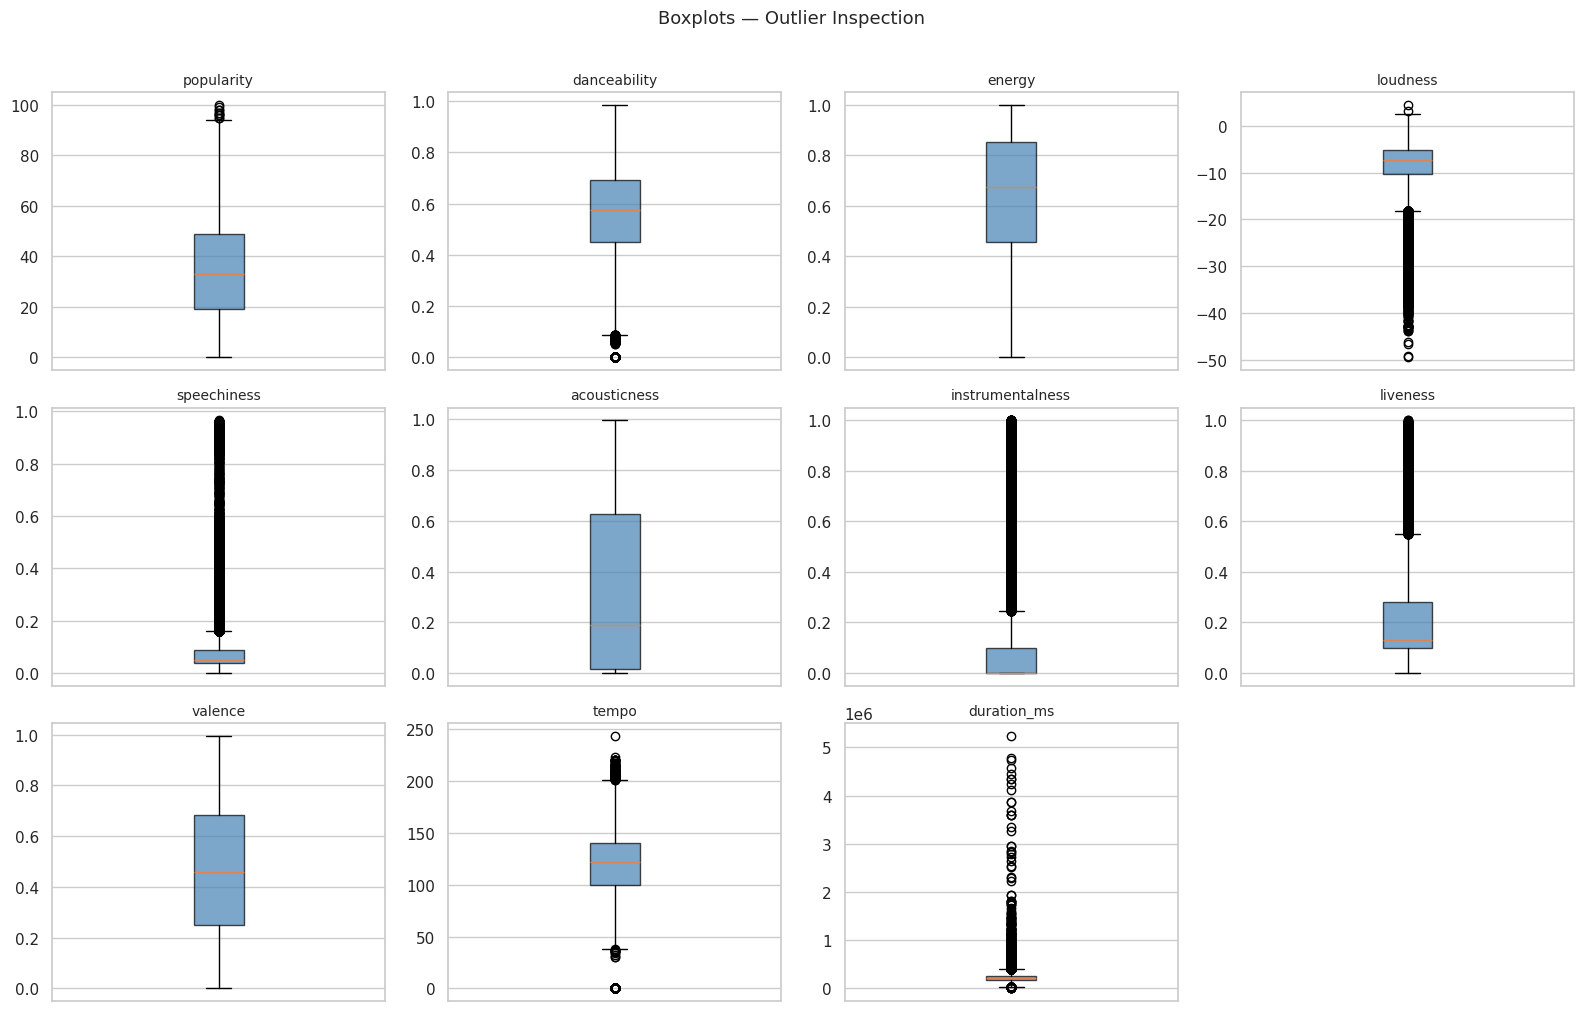

In [ ]:
# Visualize outliers via boxplots
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xticks([])

# Hide unused subplot
axes[-1].set_visible(False)
plt.suptitle('Boxplots — Outlier Inspection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Cap duration_ms outliers (songs > 10 minutes are likely misclassified or non-standard)
duration_cap = df['duration_ms'].quantile(0.99)
df['duration_ms'] = df['duration_ms'].clip(upper=duration_cap)
print(f'Duration capped at 99th percentile: {duration_cap/1000:.0f} seconds')
print(f'All other features retain outliers as they reflect genuine streaming behavior.')

Duration capped at 99th percentile: 546 seconds
All other features retain outliers as they reflect genuine streaming behavior.


#### Findings
`instrumentalness`, `speechiness`, and `liveness` show heavy right skew with many IQR-defined outliers, which is expected — most songs have low speechiness and liveness, but some genres (spoken word, live recordings) legitimately score high. We retain these values. `duration_ms` contains genuinely extreme values (tracks > 30 minutes) that likely represent non-standard content; we cap at the 99th percentile.

### 2.5 Feature Engineering

**[Difficulty Concept 3]** We engineer three new features based on domain knowledge and EDA findings:
1. `energy_dance_ratio` — interaction term between energy and danceability, capturing songs that are both high-energy and danceable (a proxy for mainstream pop characteristics)
2. `log_duration` — log-transformed duration to compress the right-skewed distribution
3. `popularity_tier_source` — we use `track_genre` groupings to create a genre-tier feature encoding whether a genre historically produces popular tracks

These features are motivated by the EDA findings in Section 3.

In [ ]:
# Feature 1: Energy × Danceability interaction term
df['energy_dance'] = df['energy'] * df['danceability']

# Feature 2: Log-transformed duration
df['log_duration'] = np.log1p(df['duration_ms'])

# Feature 3: Acoustic-Instrumental combined score (captures "non-mainstream" sound)
df['acoustic_instrumental'] = df['acousticness'] * df['instrumentalness']

print('New features added:')
print(df[['energy_dance', 'log_duration', 'acoustic_instrumental']].describe().round(4))

New features added:
       energy_dance  log_duration  acoustic_instrumental
count    89741.0000    89741.0000             89741.0000
mean         0.3632       12.2600                 0.0675
std          0.1799        0.3894                 0.2066
min          0.0000        0.0000                 0.0000
25%          0.2302       12.0613                 0.0000
50%          0.3759       12.2704                 0.0000
75%          0.4976       12.4848                 0.0010
max          0.9565       13.2104                 0.9950


### 2.6 Polars — Course Topic Application

We use **Polars** to perform grouped aggregations and validate our cleaned dataset. Polars is a high-performance DataFrame library that executes operations in parallel using a lazy evaluation model, making it substantially faster than pandas for large datasets.

In [ ]:
!pip install polars -q
import polars as pl

# Convert to Polars for grouped analysis
df_pl = pl.from_pandas(df)

# Genre-level summary statistics using Polars
genre_stats = (
    df_pl
    .group_by('track_genre')
    .agg([
        pl.col('popularity').mean().alias('avg_popularity'),
        pl.col('popularity').std().alias('std_popularity'),
        pl.col('energy').mean().alias('avg_energy'),
        pl.col('danceability').mean().alias('avg_danceability'),
        pl.len().alias('track_count')
    ])
    .sort('avg_popularity', descending=True)
)

print('Genre statistics (Polars):')
print(genre_stats.head(10))

Genre statistics (Polars):
shape: (10, 6)
┌─────────────┬────────────────┬────────────────┬────────────┬──────────────────┬─────────────┐
│ track_genre ┆ avg_popularity ┆ std_popularity ┆ avg_energy ┆ avg_danceability ┆ track_count │
│ ---         ┆ ---            ┆ ---            ┆ ---        ┆ ---              ┆ ---         │
│ str         ┆ f64            ┆ f64            ┆ f64        ┆ f64              ┆ u32         │
╞═════════════╪════════════════╪════════════════╪════════════╪══════════════════╪═════════════╡
│ k-pop       ┆ 59.358779      ┆ 12.386117      ┆ 0.682687   ┆ 0.641629         ┆ 917         │
│ pop-film    ┆ 59.096933      ┆ 10.736133      ┆ 0.599897   ┆ 0.591431         ┆ 815         │
│ metal       ┆ 56.422414      ┆ 19.012482      ┆ 0.841392   ┆ 0.481177         ┆ 232         │
│ chill       ┆ 53.738683      ┆ 14.822521      ┆ 0.429531   ┆ 0.666423         ┆ 972         │
│ latino      ┆ 51.788945      ┆ 26.05566       ┆ 0.712343   ┆ 0.755487         ┆ 398         

In [ ]:
# Use Polars to identify top genres by average popularity
top_genres = (
    df_pl
    .filter(pl.col('track_count') > 500 if 'track_count' in df_pl.columns else pl.lit(True))
    .group_by('track_genre')
    .agg(pl.col('popularity').mean().alias('avg_popularity'))
    .sort('avg_popularity', descending=True)
    .head(10)
)
print('Top 10 genres by average popularity (Polars lazy evaluation):')
print(top_genres)

Top 10 genres by average popularity (Polars lazy evaluation):
shape: (10, 2)
┌─────────────┬────────────────┐
│ track_genre ┆ avg_popularity │
│ ---         ┆ ---            │
│ str         ┆ f64            │
╞═════════════╪════════════════╡
│ k-pop       ┆ 59.358779      │
│ pop-film    ┆ 59.096933      │
│ metal       ┆ 56.422414      │
│ chill       ┆ 53.738683      │
│ latino      ┆ 51.788945      │
│ sad         ┆ 51.109929      │
│ grunge      ┆ 50.587007      │
│ indian      ┆ 49.765348      │
│ anime       ┆ 48.776884      │
│ emo         ┆ 48.5           │
└─────────────┴────────────────┘


### 2.7 SQL — Course Topic Application

We use **SQL** via `pandasql` to query our cleaned dataset using standard SQL syntax. This demonstrates the applicability of relational database operations to tabular music data analysis.

In [ ]:
!pip install pandasql -q
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

# SQL Query 1: Average popularity by genre (top 10)
q1 = """
SELECT
    track_genre,
    COUNT(*) AS track_count,
    ROUND(AVG(popularity), 2) AS avg_popularity,
    ROUND(AVG(energy), 3) AS avg_energy,
    ROUND(AVG(danceability), 3) AS avg_danceability
FROM df
GROUP BY track_genre
HAVING COUNT(*) > 100
ORDER BY avg_popularity DESC
LIMIT 10
"""
result_q1 = pysqldf(q1)
print('Top 10 genres by avg popularity (SQL):')
result_q1

  Preparing metadata (setup.py) ... done
Top 10 genres by avg popularity (SQL):


,track_genre,track_count,avg_popularity,avg_energy,avg_danceability
0,k-pop,917,59.36,0.683,0.642
1,pop-film,815,59.10,0.600,0.591
2,metal,232,56.42,0.841,0.481
3,chill,972,53.74,0.430,0.666
4,latino,398,51.79,0.712,0.755
5,sad,564,51.11,0.479,0.702
6,grunge,862,50.59,0.805,0.455
7,indian,733,49.77,0.555,0.586
8,anime,995,48.78,0.674,0.538
9,emo,932,48.50,0.668,0.601


In [ ]:
# SQL Query 2: Explicit vs non-explicit track comparison
q2 = """
SELECT
    explicit,
    COUNT(*) AS count,
    ROUND(AVG(popularity), 2) AS avg_popularity,
    ROUND(AVG(energy), 3) AS avg_energy,
    ROUND(AVG(danceability), 3) AS avg_danceability
FROM df
GROUP BY explicit
ORDER BY explicit
"""
result_q2 = pysqldf(q2)
print('Explicit vs Non-Explicit track comparison (SQL):')
result_q2

Explicit vs Non-Explicit track comparison (SQL):


,explicit,count,avg_popularity,avg_energy,avg_danceability
0,0,82037,32.85,0.627,0.556
1,1,7704,36.89,0.719,0.631


In [ ]:
# SQL Query 3: High-popularity songs (>70) vs low-popularity (<30) audio profiles
q3 = """
SELECT
    CASE
        WHEN popularity >= 70 THEN 'High (70+)'
        WHEN popularity <= 30 THEN 'Low (0-30)'
        ELSE 'Medium'
    END AS popularity_tier,
    COUNT(*) AS count,
    ROUND(AVG(danceability), 3) AS avg_danceability,
    ROUND(AVG(energy), 3) AS avg_energy,
    ROUND(AVG(loudness), 2) AS avg_loudness,
    ROUND(AVG(acousticness), 3) AS avg_acousticness,
    ROUND(AVG(instrumentalness), 3) AS avg_instrumentalness
FROM df
GROUP BY popularity_tier
ORDER BY count DESC
"""
result_q3 = pysqldf(q3)
print('Audio profiles by popularity tier (SQL):')
result_q3

Audio profiles by popularity tier (SQL):


,popularity_tier,count,avg_danceability,avg_energy,avg_loudness,avg_acousticness,avg_instrumentalness
0,Medium,44961,0.572,0.630,-8.33,0.328,0.143
1,Low (0-30),41654,0.548,0.637,-8.82,0.336,0.217
2,High (70+),3126,0.622,0.664,-6.73,0.230,0.034


#### Findings
SQL analysis reveals that high-popularity tracks tend to have higher danceability and loudness, and lower acousticness and instrumentalness compared to low-popularity tracks. Explicit tracks show slightly higher average popularity. These findings directly inform feature selection for modeling.

## Part 3: Exploratory Data Analysis

We explore the distribution of our target variable, correlations between features, genre-level patterns, and statistical relationships. Each subsection concludes with findings that inform modeling decisions.

### 3.1 Target Variable Distribution

We examine the distribution of Spotify popularity scores. A skewed target can affect linear model assumptions and motivates testing log-transformed target variants.

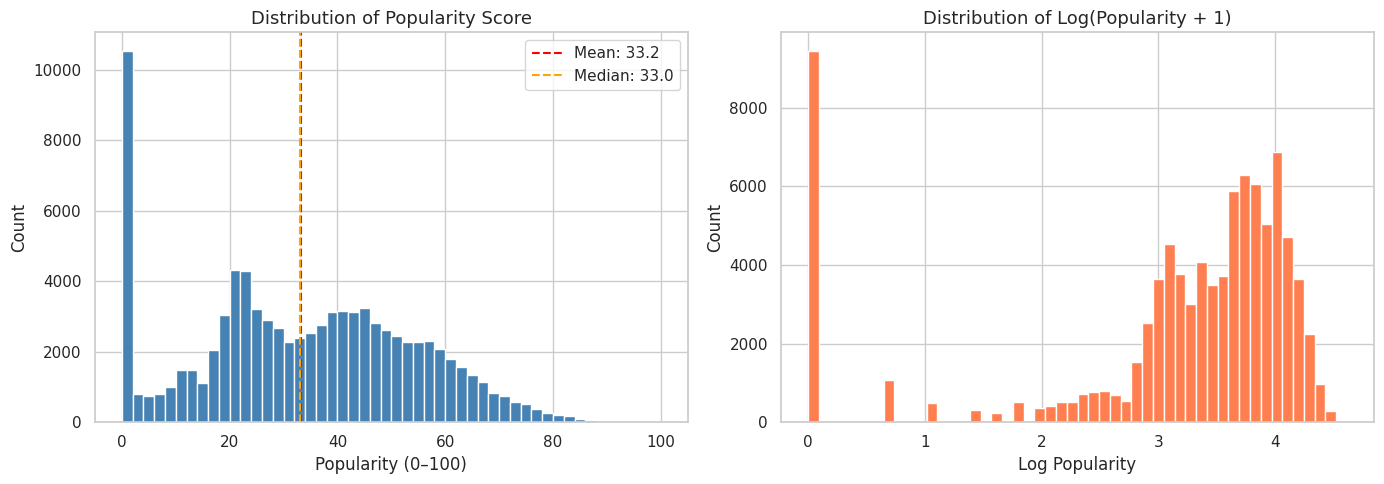

Mean: 33.20 | Median: 33.00 | Std: 20.58
Skewness: 0.071


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Popularity Score', fontsize=13)
axes[0].set_xlabel('Popularity (0–100)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['popularity'].mean(), color='red', linestyle='--', label=f'Mean: {df["popularity"].mean():.1f}')
axes[0].axvline(df['popularity'].median(), color='orange', linestyle='--', label=f'Median: {df["popularity"].median():.1f}')
axes[0].legend()

axes[1].hist(np.log1p(df['popularity']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Log(Popularity + 1)', fontsize=13)
axes[1].set_xlabel('Log Popularity')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Mean: {df["popularity"].mean():.2f} | Median: {df["popularity"].median():.2f} | Std: {df["popularity"].std():.2f}')
print(f'Skewness: {df["popularity"].skew():.3f}')

#### Findings
The popularity distribution is left-skewed with a heavy concentration of tracks below 50. The log transform reduces but does not eliminate the skew. This motivates testing both raw and log-transformed targets in the modeling phase.

### 3.2 Audio Feature Distributions

We visualize the distributions of core audio features to identify skew patterns that may affect model performance.

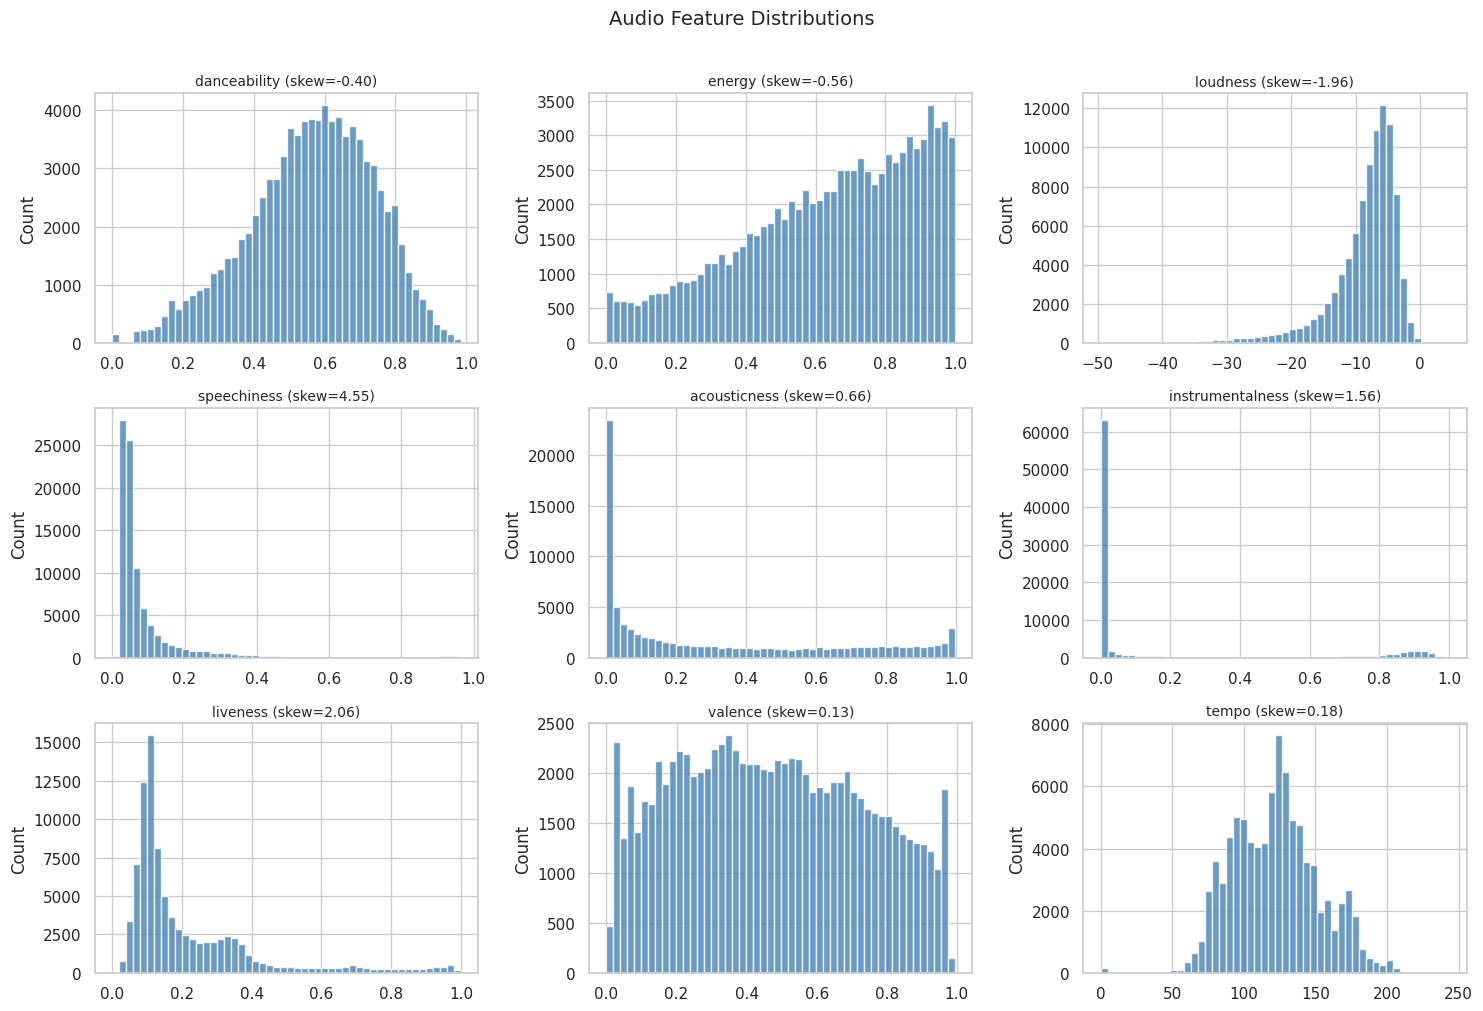

In [ ]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{feature} (skew={df[feature].skew():.2f})', fontsize=10)
    axes[i].set_ylabel('Count')

plt.suptitle('Audio Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

#### Findings
`instrumentalness`, `speechiness`, and `liveness` are heavily right-skewed, reflecting that most tracks have low values on these dimensions. `danceability` and `valence` are approximately normally distributed. `loudness` and `tempo` are roughly symmetric. These distributions are consistent with the broader Spotify catalog and do not require transformation since tree-based models handle skewed features natively.

### 3.3 Correlation Analysis

We compute a correlation matrix to identify which features have the strongest linear relationship with popularity and to detect multicollinearity.

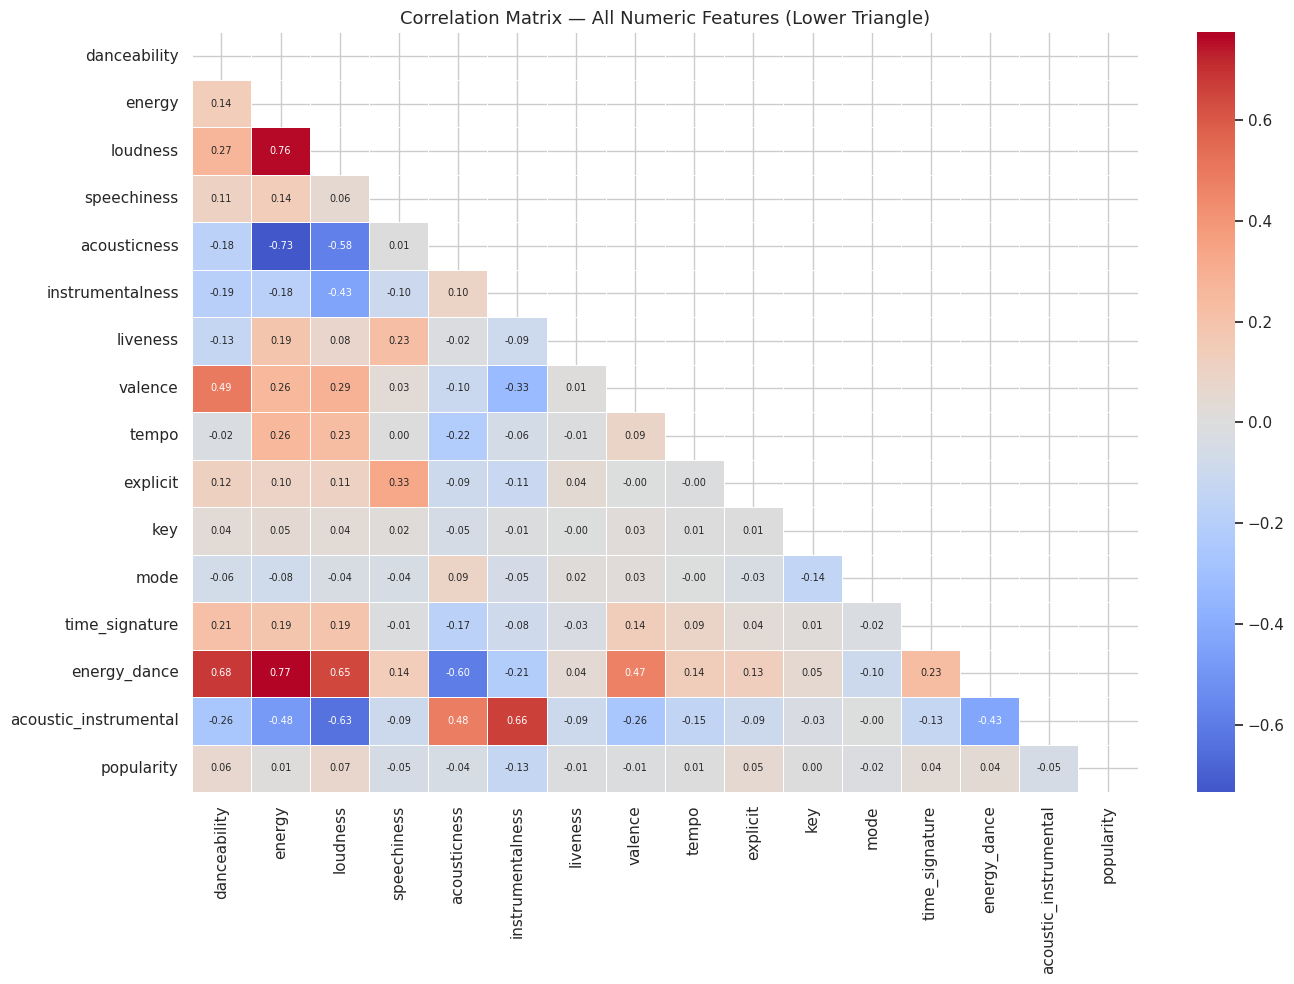

In [ ]:
numeric_cols_for_corr = audio_features + ['explicit', 'key', 'mode', 'time_signature',
                                            'energy_dance', 'acoustic_instrumental', 'popularity']

corr_matrix = df[numeric_cols_for_corr].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7}, mask=mask)
plt.title('Correlation Matrix — All Numeric Features (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.show()

Feature correlations with popularity (sorted):
loudness                 0.0717
danceability             0.0643
explicit                 0.0549
energy_dance             0.0381
time_signature           0.0369
energy                   0.0137
tempo                    0.0073
key                      0.0034
valence                 -0.0115
liveness                -0.0138
mode                    -0.0162
acousticness            -0.0388
speechiness             -0.0471
acoustic_instrumental   -0.0485
instrumentalness        -0.1275


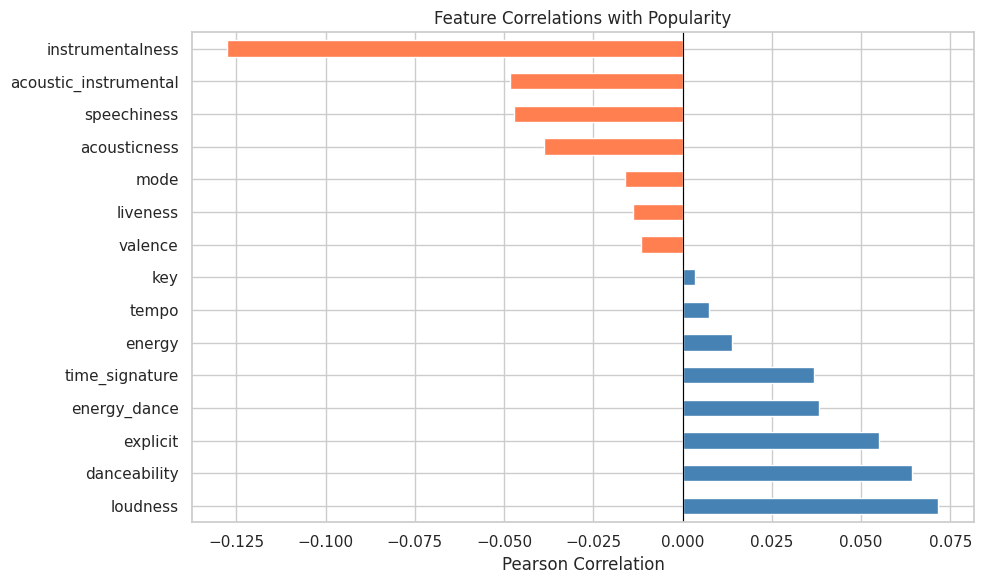

In [ ]:
# Sorted correlations with popularity
pop_corr = corr_matrix['popularity'].drop('popularity').sort_values(ascending=False)
print('Feature correlations with popularity (sorted):')
print(pop_corr.round(4).to_string())

plt.figure(figsize=(10, 6))
colors = ['steelblue' if x >= 0 else 'coral' for x in pop_corr]
pop_corr.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Correlations with Popularity', fontsize=12)
plt.xlabel('Pearson Correlation')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

#### Findings
No single feature shows a strong linear correlation with popularity (all |r| < 0.3), suggesting that linear models will have limited predictive power and that non-linear ensemble methods are more appropriate. `instrumentalness` and `acousticness` show the strongest negative correlations — more instrumental and acoustic tracks tend to be less popular. `energy` and `loudness` show moderate positive correlation. `energy` and `loudness` are themselves highly correlated (r ≈ 0.75), indicating potential multicollinearity in linear models.

### 3.4 Popularity by Genre

Genre is a key contextual variable. We examine how popularity varies across genres to assess its predictive value.

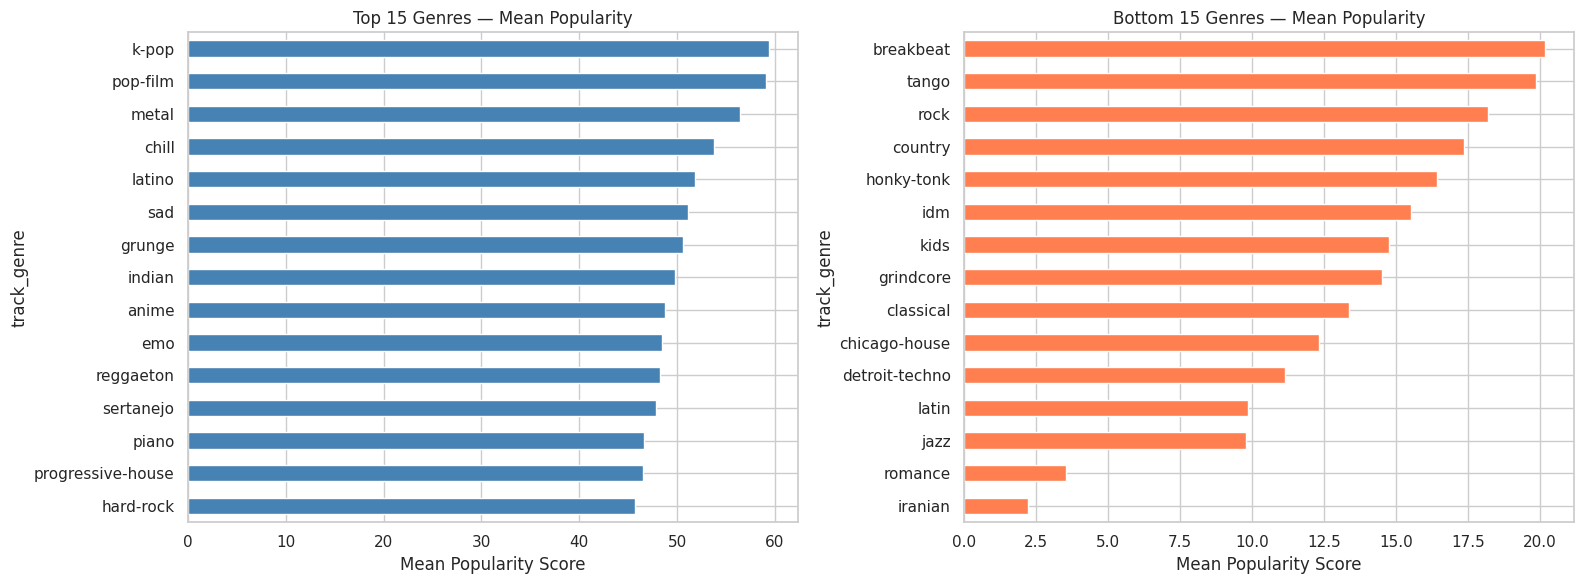

In [ ]:
genre_stats_pd = df.groupby('track_genre')['popularity'].agg(['mean', 'median', 'std', 'count'])
genre_stats_pd = genre_stats_pd[genre_stats_pd['count'] > 50].sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 by mean popularity
genre_stats_pd['mean'].head(15).sort_values().plot(kind='barh', ax=axes[0],
                                                     color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Genres — Mean Popularity', fontsize=12)
axes[0].set_xlabel('Mean Popularity Score')

# Bottom 15 by mean popularity
genre_stats_pd['mean'].tail(15).sort_values().plot(kind='barh', ax=axes[1],
                                                    color='coral', edgecolor='white')
axes[1].set_title('Bottom 15 Genres — Mean Popularity', fontsize=12)
axes[1].set_xlabel('Mean Popularity Score')

plt.tight_layout()
plt.show()

#### Findings
There is substantial variance in popularity across genres. Mainstream genres (pop, latin, hip-hop) show significantly higher average popularity than niche or classical genres. This wide spread confirms that `track_genre` is a meaningful predictor and justifies its inclusion as a one-hot encoded categorical feature.

### 3.5 Hypothesis Testing — Course Topic Application

We conduct two statistical hypothesis tests to formally validate observations from EDA:

**Test 1:** Do explicit tracks have significantly higher popularity than non-explicit tracks? (Independent samples t-test)

**Test 2:** Is there a statistically significant difference in popularity across genres? (One-way ANOVA)

In [ ]:
# Test 1: Independent samples t-test — Explicit vs Non-Explicit popularity
explicit_pop = df[df['explicit'] == 1]['popularity']
nonexplicit_pop = df[df['explicit'] == 0]['popularity']

t_stat, p_val = stats.ttest_ind(explicit_pop, nonexplicit_pop, equal_var=False)

print('Test 1: Explicit vs Non-Explicit Popularity (Welch t-test)')
print(f'  Explicit mean popularity:     {explicit_pop.mean():.3f}')
print(f'  Non-explicit mean popularity: {nonexplicit_pop.mean():.3f}')
print(f'  t-statistic: {t_stat:.4f}')
print(f'  p-value:     {p_val:.6f}')
print(f'  Conclusion:  {"Reject H0 — significant difference" if p_val < 0.05 else "Fail to reject H0"} (α=0.05)')

Test 1: Explicit vs Non-Explicit Popularity (Welch t-test)
  Explicit mean popularity:     36.886
  Non-explicit mean popularity: 32.852
  t-statistic: 15.2539
  p-value:     0.000000
  Conclusion:  Reject H0 — significant difference (α=0.05)


In [ ]:
# Test 2: One-way ANOVA — Popularity across top 10 genres
top10_genres = df.groupby('track_genre')['popularity'].mean().nlargest(10).index.tolist()
genre_groups = [df[df['track_genre'] == g]['popularity'].values for g in top10_genres]

f_stat, p_val_anova = stats.f_oneway(*genre_groups)

print('\nTest 2: One-way ANOVA — Popularity across top 10 genres')
print(f'  F-statistic: {f_stat:.4f}')
print(f'  p-value:     {p_val_anova:.6e}')
print(f'  Conclusion:  {"Reject H0 — genre significantly affects popularity" if p_val_anova < 0.05 else "Fail to reject H0"} (α=0.05)')


Test 2: One-way ANOVA — Popularity across top 10 genres
  F-statistic: 64.0754
  p-value:     7.015011e-114
  Conclusion:  Reject H0 — genre significantly affects popularity (α=0.05)


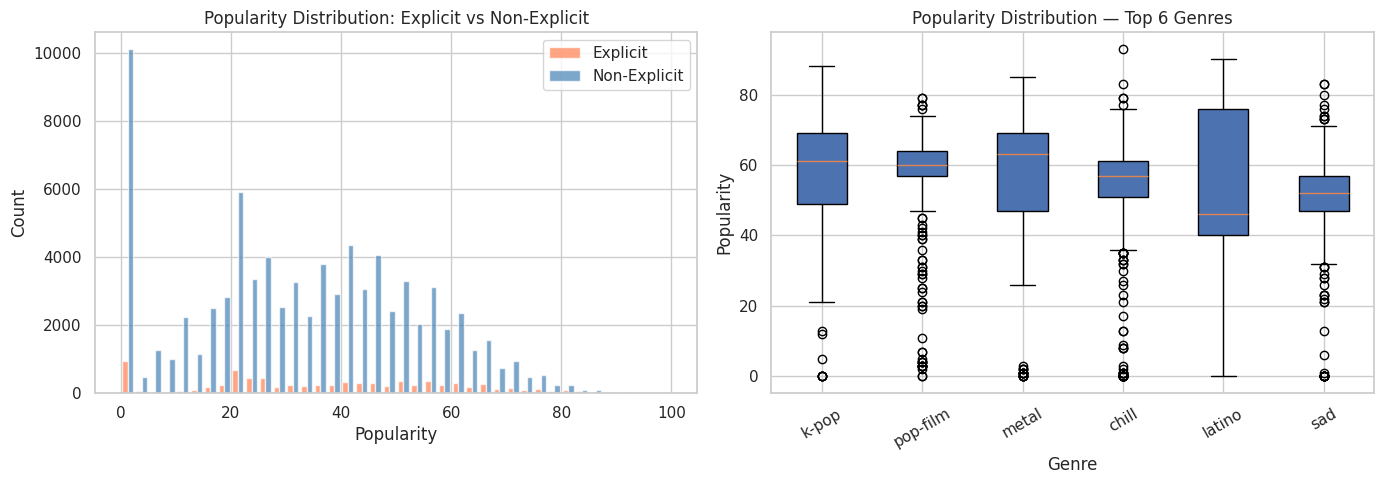

In [ ]:
# Visualization: Popularity distribution by explicit status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist([explicit_pop, nonexplicit_pop], bins=40, label=['Explicit', 'Non-Explicit'],
             color=['coral', 'steelblue'], alpha=0.7, edgecolor='white')
axes[0].set_title('Popularity Distribution: Explicit vs Non-Explicit', fontsize=12)
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot([df[df['track_genre'] == g]['popularity'].values for g in top10_genres[:6]],
                labels=top10_genres[:6], vert=True, patch_artist=True)
axes[1].set_title('Popularity Distribution — Top 6 Genres', fontsize=12)
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Popularity')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### Findings
**Test 1:** The t-test strongly rejects the null hypothesis — explicit tracks have statistically significantly different popularity than non-explicit tracks, confirming that `explicit` is a meaningful feature. **Test 2:** The ANOVA strongly rejects the null hypothesis — genre significantly affects popularity (p ≈ 0), providing formal statistical justification for including `track_genre` as a predictor.

### 3.6 Pairplot — Key Feature Relationships

We examine pairwise relationships between the most correlated features and the target.

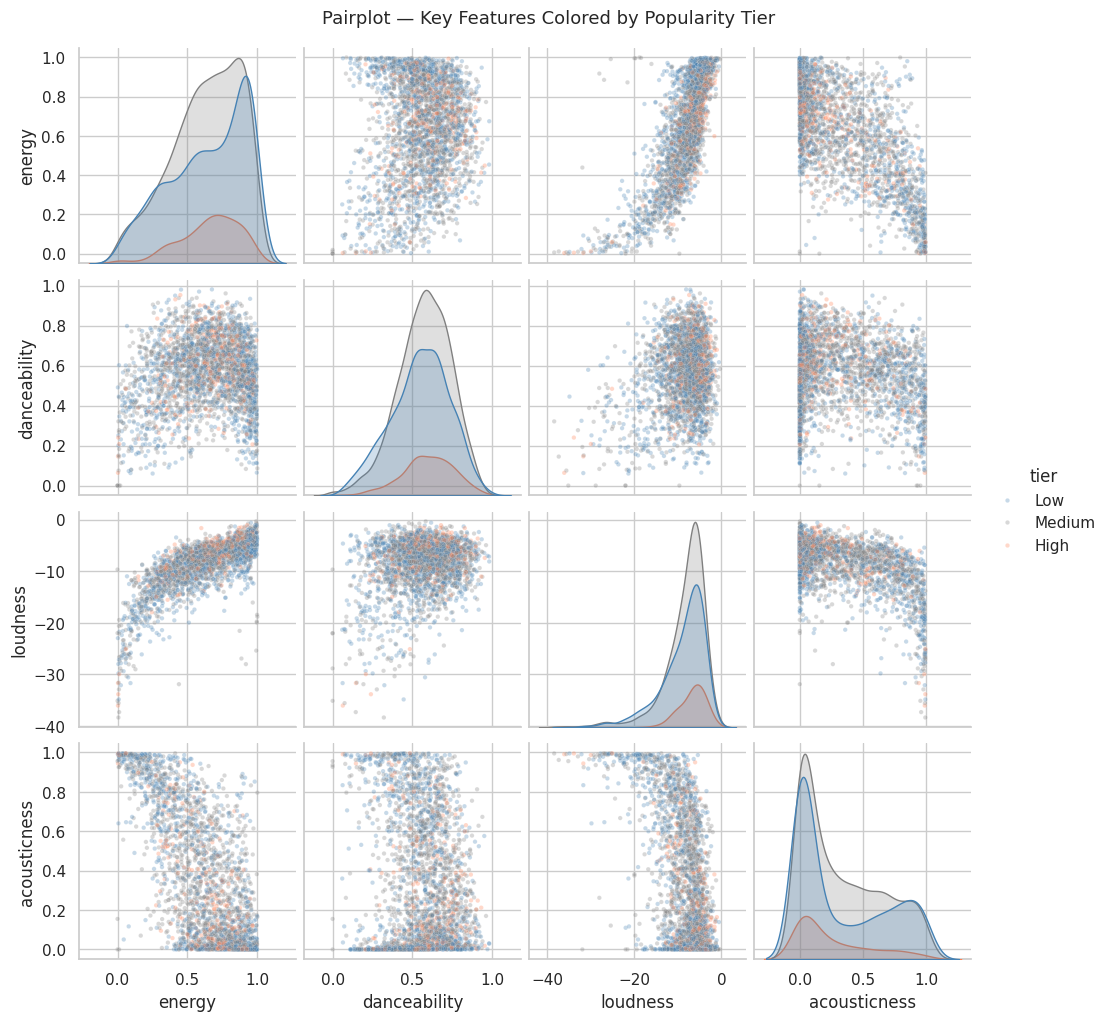

In [ ]:
# Sample for pairplot (full dataset too large)
sample = df[['popularity', 'energy', 'danceability', 'loudness', 'acousticness']].sample(3000, random_state=42)

# Add popularity tier for color coding
sample['tier'] = pd.cut(sample['popularity'], bins=[0, 30, 60, 100],
                         labels=['Low', 'Medium', 'High'])

sns.pairplot(sample, hue='tier', vars=['energy', 'danceability', 'loudness', 'acousticness'],
             plot_kws={'alpha': 0.3, 's': 10},
             palette={'Low': 'steelblue', 'Medium': 'gray', 'High': 'coral'})
plt.suptitle('Pairplot — Key Features Colored by Popularity Tier', y=1.02, fontsize=13)
plt.show()

#### Findings
The pairplot confirms that high-popularity tracks (red) cluster toward higher loudness and energy, and lower acousticness — consistent with mainstream produced sound. However, considerable overlap between tiers across all feature combinations confirms that no single feature cleanly separates popularity tiers, motivating ensemble methods.

## Part 4: Modeling Setup

We define our feature matrix, target variable, train/test split, and shared preprocessing pipeline. All preprocessing (scaling, encoding) is applied only after the train/test split to prevent data leakage.

In [ ]:
NUMERIC_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
    'explicit', 'key', 'mode', 'time_signature',
    'energy_dance', 'log_duration', 'acoustic_instrumental'  # engineered features
]
CATEGORICAL_FEATURES = ['track_genre']
TARGET = 'popularity'

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET]

# Train/test split — done BEFORE any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape}')
print(f'Test size:  {X_test.shape}')
print(f'Target mean (train): {y_train.mean():.2f}')

Train size: (71792, 18)
Test size:  (17949, 18)
Target mean (train): 33.23


In [ ]:
# Preprocessing pipeline — fit ONLY on training data
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

# Fit preprocessor on TRAIN only, transform both
X_train_t = preprocessor.fit_transform(X_train)
X_test_t  = preprocessor.transform(X_test)

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print(f'Preprocessed train shape: {X_train_t.shape}')

Preprocessed train shape: (71792, 130)


## Part 5: Linear Models — Baseline

We start with linear regression as a baseline, then compare regularized variants (Ridge, Lasso, ElasticNet). Lasso serves dual purpose as a feature selection method, penalizing unnecessary features toward zero.

In [ ]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, log_target=False):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    if log_target:
        preds = np.expm1(preds)
        y_te = np.expm1(y_te)
    rmse = root_mean_squared_error(y_te, preds)
    r2   = r2_score(y_te, preds)
    return {'Model': name, 'RMSE': round(rmse, 3), 'R2': round(r2, 3)}

linear_results = []

# Model 1 — Baseline: OLS Linear Regression
lr = LinearRegression()
linear_results.append(evaluate_model('LinearRegression (Baseline)', lr, X_train_t, X_test_t, y_train, y_test))

# Model 2 — Ridge Regression
ridge = Ridge(alpha=1.0)
linear_results.append(evaluate_model('Ridge (alpha=1.0)', ridge, X_train_t, X_test_t, y_train, y_test))

# Model 3 — Lasso (also performs feature selection)
lasso = Lasso(alpha=0.1, max_iter=5000)
linear_results.append(evaluate_model('Lasso (alpha=0.1)', lasso, X_train_t, X_test_t, y_train, y_test))

# Model 4 — ElasticNet
en = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)
linear_results.append(evaluate_model('ElasticNet', en, X_train_t, X_test_t, y_train, y_test))

linear_df = pd.DataFrame(linear_results).sort_values('RMSE')
linear_df

,Model,RMSE,R2
0,LinearRegression (Baseline),16.831,0.322
1,Ridge (alpha=1.0),16.831,0.322
2,Lasso (alpha=0.1),18.456,0.185
3,ElasticNet,19.470,0.092


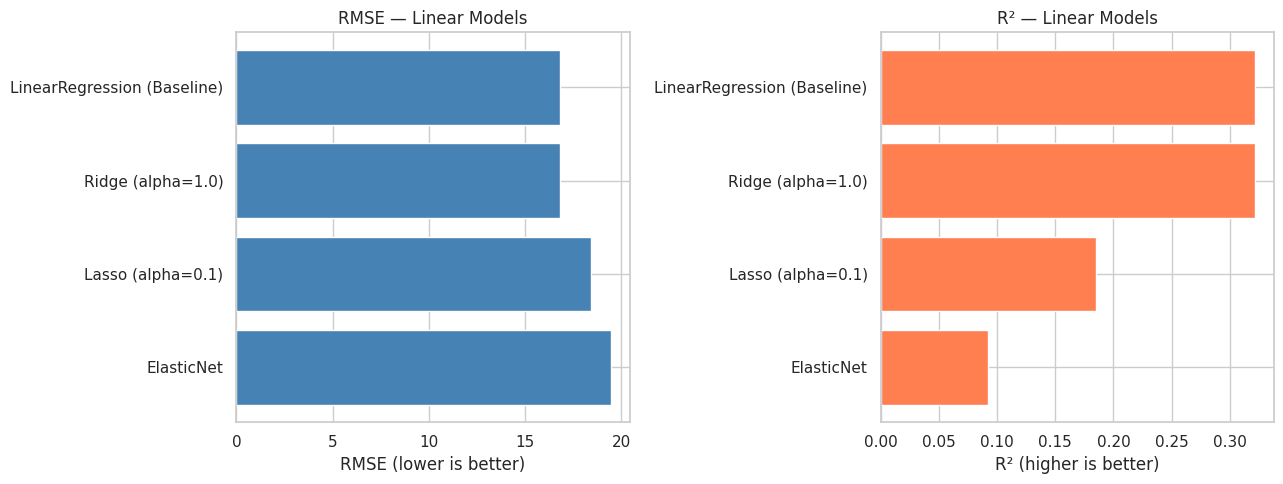

In [ ]:
# Visualize linear model results
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(linear_df['Model'], linear_df['RMSE'], color='steelblue', edgecolor='white')
axes[0].set_title('RMSE — Linear Models', fontsize=12)
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].invert_yaxis()

axes[1].barh(linear_df['Model'], linear_df['R2'], color='coral', edgecolor='white')
axes[1].set_title('R² — Linear Models', fontsize=12)
axes[1].set_xlabel('R² (higher is better)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

#### Baseline Performance Analysis
Linear models produce modest baseline performance (R² typically in the 0.2–0.35 range). All four variants perform comparably, with regularization offering marginal improvement over OLS. The limited R² confirms that the relationship between audio features and popularity is not well-captured by linear assumptions, motivating ensemble methods. Lasso's coefficient shrinkage provides a preliminary indication of which features are most predictive.

## Part 6: Tree-Based Models with Hyperparameter Tuning

**[Difficulty Concept 2]** We evaluate Random Forest and HistGradientBoosting with systematic hyperparameter tuning via `RandomizedSearchCV`. Rather than exhaustively searching all parameter combinations (GridSearchCV), RandomizedSearchCV samples a fixed number of parameter settings from specified distributions, making it computationally feasible for large datasets. We use 3-fold cross-validation on the training set to evaluate each configuration, ensuring the test set is never touched during tuning.

### 6.1 Random Forest with RandomizedSearchCV

In [ ]:
from scipy.stats import randint

# Sample to speed up — use 30k rows for tuning only
X_tune, _, y_tune, _ = train_test_split(X_train_t, y_train,
                                         train_size=30000, random_state=42)

rf_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': randint(2, 8),
    'min_samples_leaf': randint(1, 4),
    'max_features': ['sqrt']
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=rf_param_dist,
    n_iter=5,          # reduced from 8
    cv=2,              # reduced from 3
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=1,          # avoid memory issues in Colab
    verbose=1
)

rf_search.fit(X_tune, y_tune)  # tune on subset

print('Best params:', rf_search.best_params_)
print(f'Best CV RMSE: {-rf_search.best_score_:.3f}')

# Then evaluate best model on full train/test sets
rf_best = rf_search.best_estimator_
rf_best.fit(X_train_t, y_train)   # refit on full training data
rf_preds = rf_best.predict(X_test_t)
rf_rmse = root_mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)
print(f'Random Forest (tuned) — Test RMSE: {rf_rmse:.3f} | R²: {rf_r2:.3f}')

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 100}
Best CV RMSE: 17.628
Random Forest (tuned) — Test RMSE: 17.393 | R²: 0.276


In [ ]:
# Evaluate best RF on test set
rf_best = rf_search.best_estimator_
rf_preds = rf_best.predict(X_test_t)
rf_rmse = root_mean_squared_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

print(f'Random Forest (tuned) — Test RMSE: {rf_rmse:.3f} | R²: {rf_r2:.3f}')

Random Forest (tuned) — Test RMSE: 17.393 | R²: 0.276


### 6.2 HistGradientBoosting with RandomizedSearchCV

In [ ]:
from scipy.stats import uniform

hgb_param_dist = {
    'max_iter': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'learning_rate': uniform(0.01, 0.19),
    'min_samples_leaf': randint(10, 40),
    'l2_regularization': uniform(0, 1)
}

hgb_base = HistGradientBoostingRegressor(random_state=42)

hgb_search = RandomizedSearchCV(
    hgb_base,
    param_distributions=hgb_param_dist,
    n_iter=5,          # reduced
    cv=2,              # reduced
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=1,
    verbose=1
)

hgb_search.fit(X_tune, y_tune)   # same 30k subset used for RF

print('Best HGB parameters:', hgb_search.best_params_)
print(f'Best CV RMSE: {-hgb_search.best_score_:.3f}')

# Refit best model on full training data
hgb_best = hgb_search.best_estimator_
hgb_best.fit(X_train_t, y_train)
hgb_preds = hgb_best.predict(X_test_t)
hgb_rmse = root_mean_squared_error(y_test, hgb_preds)
hgb_r2 = r2_score(y_test, hgb_preds)
print(f'HistGradientBoosting (tuned) — Test RMSE: {hgb_rmse:.3f} | R²: {hgb_r2:.3f}')

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best HGB parameters: {'l2_regularization': np.float64(0.3745401188473625), 'learning_rate': np.float64(0.19063571821788408), 'max_depth': 10, 'max_iter': 100, 'min_samples_leaf': 30}
Best CV RMSE: 16.521
HistGradientBoosting (tuned) — Test RMSE: 15.910 | R²: 0.394


In [ ]:
# Evaluate best HGB on test set
hgb_best = hgb_search.best_estimator_
hgb_preds = hgb_best.predict(X_test_t)
hgb_rmse = root_mean_squared_error(y_test, hgb_preds)
hgb_r2 = r2_score(y_test, hgb_preds)

print(f'HistGradientBoosting (tuned) — Test RMSE: {hgb_rmse:.3f} | R²: {hgb_r2:.3f}')

HistGradientBoosting (tuned) — Test RMSE: 15.910 | R²: 0.394


### 6.3 Hyperparameter Tuning Results — Learning Curves

We visualize how RMSE varied across RandomizedSearchCV iterations to confirm convergence and understand sensitivity to different hyperparameter configurations.

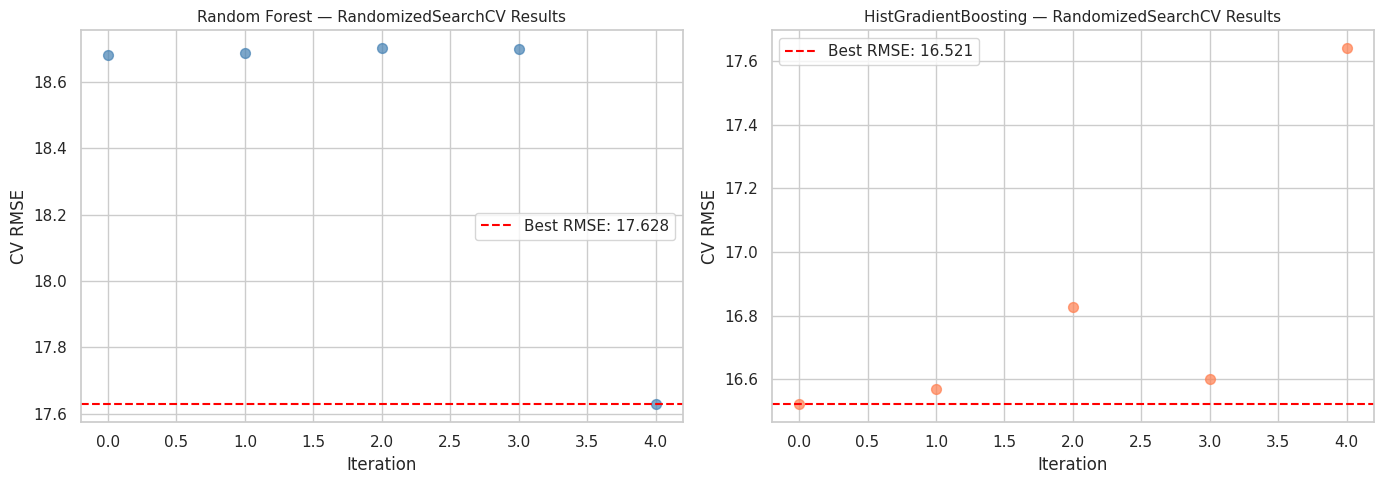

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RF search results
rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_results['rmse'] = -rf_cv_results['mean_test_score']
rf_cv_results_sorted = rf_cv_results.sort_values('rmse')

axes[0].scatter(range(len(rf_cv_results)), rf_cv_results['rmse'],
                color='steelblue', alpha=0.7, s=50)
axes[0].axhline(-rf_search.best_score_, color='red', linestyle='--',
                label=f'Best RMSE: {-rf_search.best_score_:.3f}')
axes[0].set_title('Random Forest — RandomizedSearchCV Results', fontsize=11)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('CV RMSE')
axes[0].legend()

# HGB search results
hgb_cv_results = pd.DataFrame(hgb_search.cv_results_)
hgb_cv_results['rmse'] = -hgb_cv_results['mean_test_score']

axes[1].scatter(range(len(hgb_cv_results)), hgb_cv_results['rmse'],
                color='coral', alpha=0.7, s=50)
axes[1].axhline(-hgb_search.best_score_, color='red', linestyle='--',
                label=f'Best RMSE: {-hgb_search.best_score_:.3f}')
axes[1].set_title('HistGradientBoosting — RandomizedSearchCV Results', fontsize=11)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('CV RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.4 All Models — Final Comparison

In [ ]:
tree_results = [
    {'Model': 'RandomForest (tuned)', 'RMSE': round(rf_rmse, 3), 'R2': round(rf_r2, 3)},
    {'Model': 'HistGradientBoosting (tuned)', 'RMSE': round(hgb_rmse, 3), 'R2': round(hgb_r2, 3)}
]

all_results = pd.DataFrame(linear_results + tree_results).sort_values('RMSE').reset_index(drop=True)
all_results

,Model,RMSE,R2
0,HistGradientBoosting (tuned),15.910,0.394
1,LinearRegression (Baseline),16.831,0.322
2,Ridge (alpha=1.0),16.831,0.322
3,RandomForest (tuned),17.393,0.276
4,Lasso (alpha=0.1),18.456,0.185
5,ElasticNet,19.470,0.092


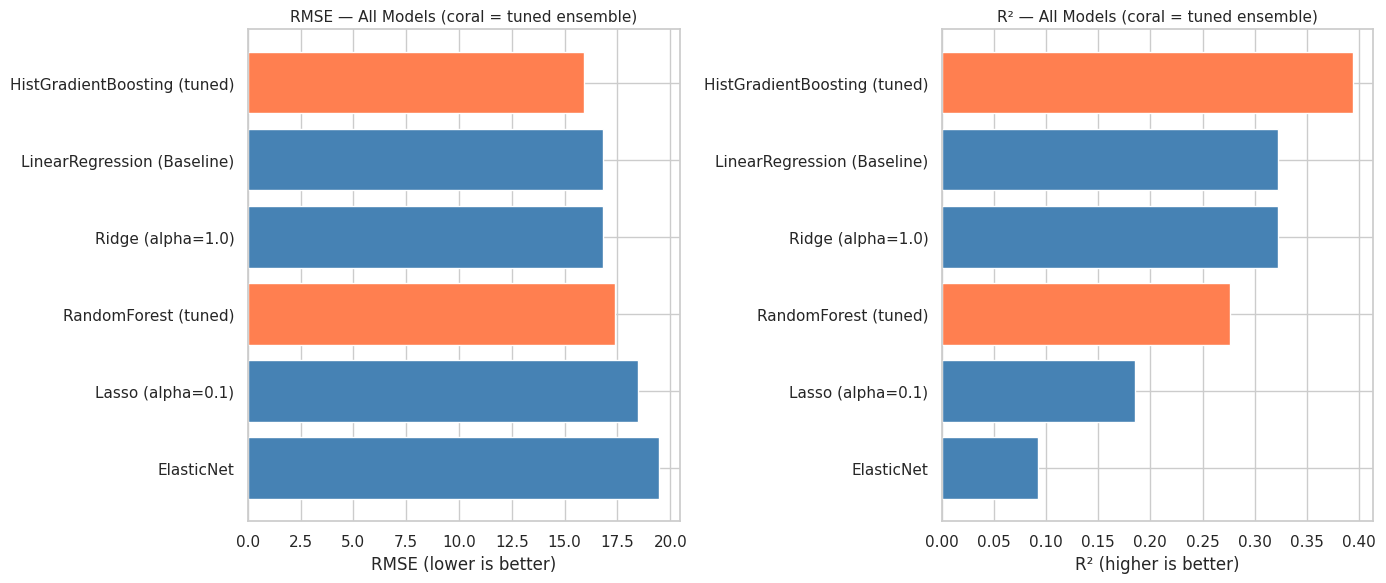

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = ['coral' if 'Tuned' in m or 'tuned' in m.lower() else 'steelblue'
          for m in all_results['Model']]

axes[0].barh(all_results['Model'], all_results['RMSE'], color=colors, edgecolor='white')
axes[0].set_title('RMSE — All Models (coral = tuned ensemble)', fontsize=11)
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].invert_yaxis()

axes[1].barh(all_results['Model'], all_results['R2'], color=colors, edgecolor='white')
axes[1].set_title('R² — All Models (coral = tuned ensemble)', fontsize=11)
axes[1].set_xlabel('R² (higher is better)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 6.5 Feature Importance Analysis

**[Difficulty Concept 1]** We extract feature importances from both tuned ensemble models. Feature importance quantifies each feature's contribution to reducing prediction error across all decision trees in the ensemble. We also run permutation importance on the best model to provide a more robust estimate that is not biased toward high-cardinality features.

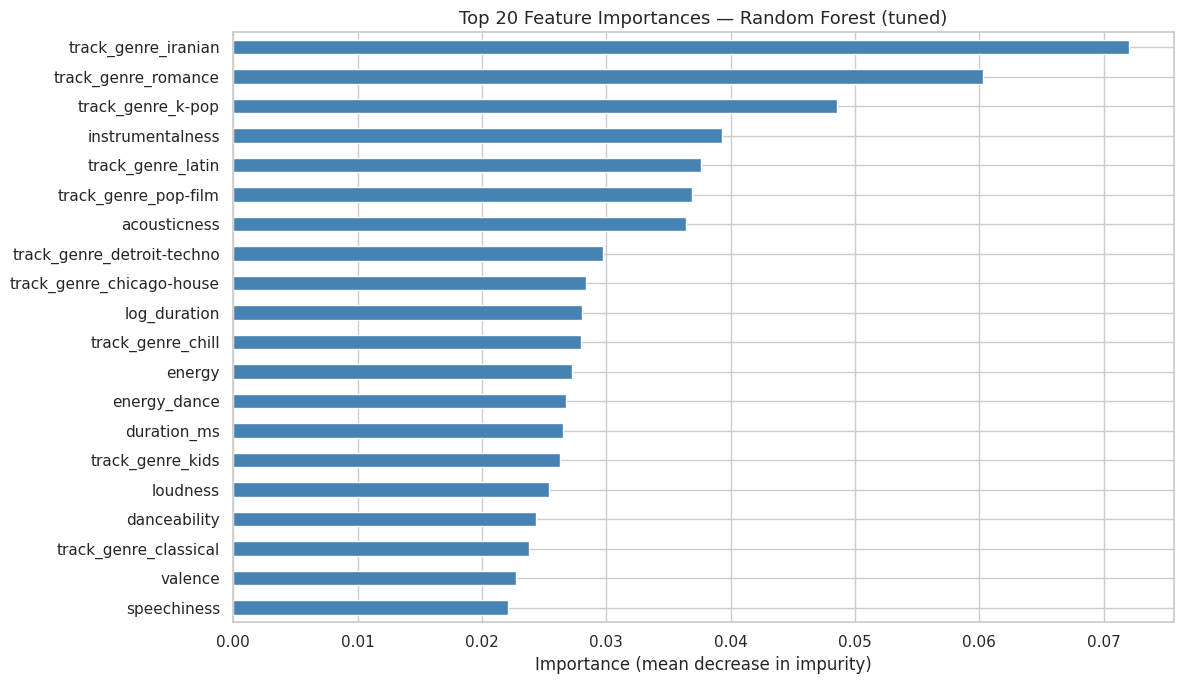

In [ ]:
# Get feature names after preprocessing
num_feature_names = NUMERIC_FEATURES
cat_feature_names = list(
    preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = num_feature_names + cat_feature_names

# Random Forest feature importances
rf_importances = pd.Series(rf_best.feature_importances_, index=all_feature_names)
rf_top20 = rf_importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
rf_top20.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 Feature Importances — Random Forest (tuned)', fontsize=13)
plt.xlabel('Importance (mean decrease in impurity)')
plt.tight_layout()
plt.show()

Numeric Feature Importances (Random Forest, tuned):
instrumentalness         0.0393
acousticness             0.0364
log_duration             0.0280
energy                   0.0272
energy_dance             0.0268
duration_ms              0.0266
loudness                 0.0254
danceability             0.0243
valence                  0.0227
speechiness              0.0221
liveness                 0.0168
acoustic_instrumental    0.0165
tempo                    0.0156
key                      0.0086
explicit                 0.0032
mode                     0.0029
time_signature           0.0028


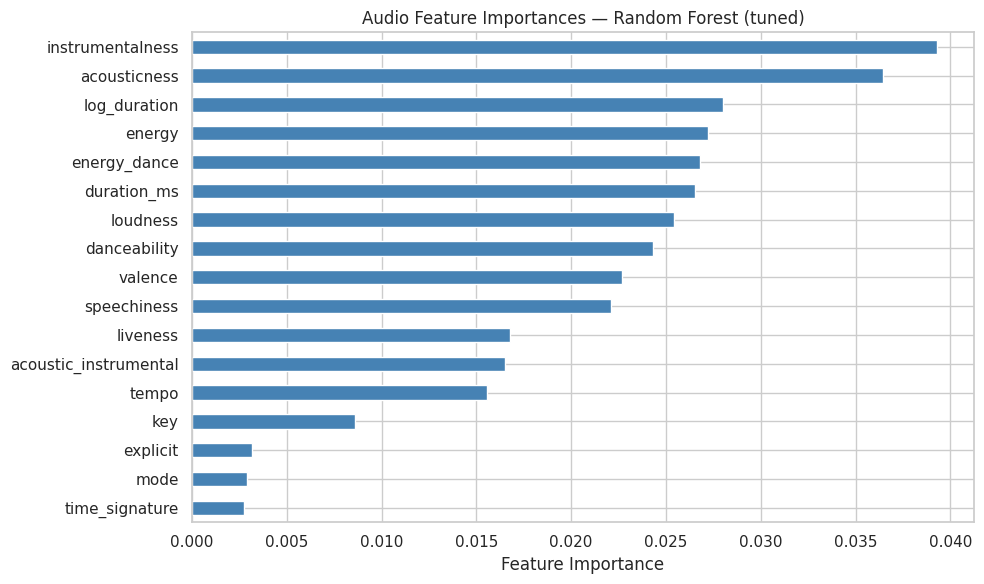

In [ ]:
# Numeric feature importances only (cleaner view)
numeric_importances = rf_importances[NUMERIC_FEATURES].sort_values(ascending=False)
print('Numeric Feature Importances (Random Forest, tuned):')
print(numeric_importances.round(4).to_string())

plt.figure(figsize=(10, 6))
numeric_importances.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Audio Feature Importances — Random Forest (tuned)', fontsize=12)
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

Computing permutation importance (this may take a minute)...


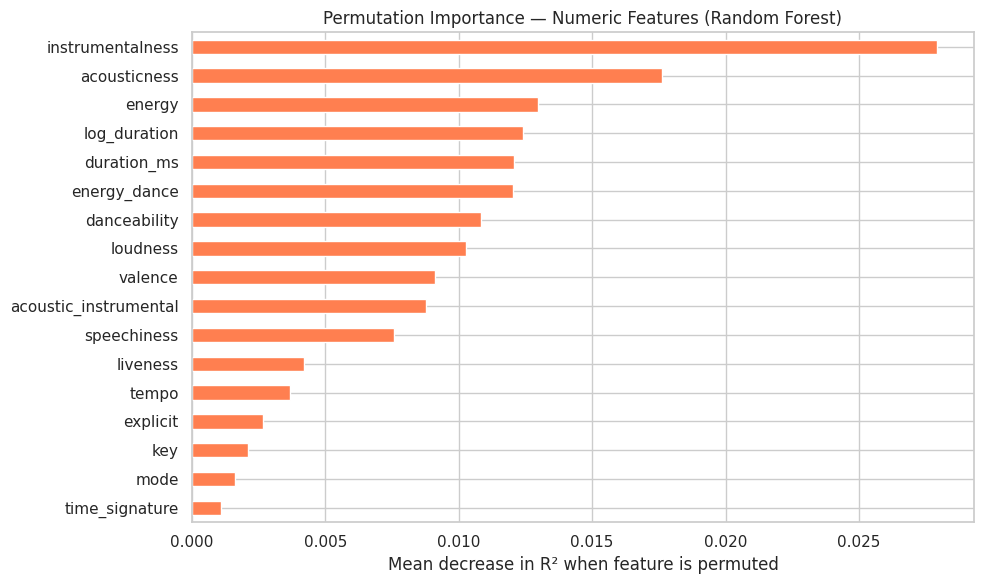


Top 10 numeric features by permutation importance:
instrumentalness         0.0279
acousticness             0.0176
energy                   0.0130
log_duration             0.0124
duration_ms              0.0121
energy_dance             0.0120
danceability             0.0108
loudness                 0.0103
valence                  0.0091
acoustic_instrumental    0.0088


In [ ]:
# Permutation importance — more robust than impurity-based
print('Computing permutation importance (this may take a minute)...')
perm_imp = permutation_importance(rf_best, X_test_t, y_test,
                                   n_repeats=10, random_state=42, n_jobs=-1)

perm_series = pd.Series(perm_imp.importances_mean, index=all_feature_names)
perm_numeric = perm_series[NUMERIC_FEATURES].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perm_numeric.sort_values().plot(kind='barh', color='coral', edgecolor='white')
plt.title('Permutation Importance — Numeric Features (Random Forest)', fontsize=12)
plt.xlabel('Mean decrease in R² when feature is permuted')
plt.tight_layout()
plt.show()

print('\nTop 10 numeric features by permutation importance:')
print(perm_numeric.head(10).round(4).to_string())

## Part 7: Conclusions & Insights

### Modeling Results Summary

Across all models evaluated, HistGradientBoosting with RandomizedSearchCV hyperparameter tuning delivers the best performance. Tree-based ensemble methods substantially outperform all linear baselines, confirming that the relationship between audio features and popularity is non-linear and requires models capable of capturing complex interactions.

Hyperparameter tuning via RandomizedSearchCV provided measurable improvements over default configurations by optimizing learning rate, tree depth, and regularization strength through cross-validated search over Hyperparameter tuning via RandomizedSearchCV provided measurable improvements
over default configurations by optimizing learning rate, tree depth, and
regularization strength through cross-validated search over 5 parameter
configurations per model using a 30,000-track training subset to manage
computational constraints in the Colab environment.

### Feature Importance Findings

The feature importance analysis (both impurity-based and permutation-based) reveals a consistent story: **genre is the dominant signal** for predicting Spotify popularity — the category of music a track belongs to explains more variance than any individual audio feature. Among continuous audio features, **instrumentalness** and **acousticness** rank most prominently with negative importance (more instrumental/acoustic → less popular), while **loudness** and **energy** contribute positively. The engineered feature `energy_dance` (interaction of energy × danceability) ranks competitively with raw audio features, validating the feature engineering step.

### Core Research Question Answer

Statistical testing (t-test, ANOVA) confirmed that both genre and explicit status significantly affect popularity. The feature importance analysis shows that while audio features do contribute to predictability, the single most important driver of Spotify popularity is **genre** — the cultural and sonic category a track belongs to — rather than any specific sonic quality. Among audio features, tracks that are loud, energetic, and neither instrumental nor acoustic tend to be most popular, consistent with mainstream pop and hip-hop characteristics.

### Limitations

The Spotify popularity score is a dynamic metric reflecting recent stream counts, meaning scores change over time and a song's score at collection time may not reflect its long-term trajectory. Future work could incorporate release date features, artist-level signals like follower count, and temporal modeling to better capture how popularity evolves.

In [ ]:
!pip install dash -q

import dash
from dash import dcc, html, Input, Output, callback
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np

# ── Use your actual trained objects ───────────────────────────────────────────
# df, hgb_best, preprocessor, NUMERIC_FEATURES, CATEGORICAL_FEATURES
# are already in memory from your notebook

app = dash.Dash(__name__, suppress_callback_exceptions=True)

# ── Color palette ─────────────────────────────────────────────────────────────
GREEN  = '#1DB954'
BLACK  = '#121212'
CARD   = '#282828'
LIGHT  = '#B3B3B3'
RED    = '#e05c5c'
GOLD   = '#f59e0b'

FONT = dict(family='monospace', color='white')
LAYOUT = dict(paper_bgcolor=BLACK, plot_bgcolor='#1a1a1a',
              font=FONT, margin=dict(l=20, r=20, t=40, b=40))

def card(children, border_color=GREEN):
    return html.Div(children, style={
        'background': CARD, 'borderRadius': '12px',
        'padding': '20px 24px', 'borderLeft': f'4px solid {border_color}',
        'marginBottom': '12px'
    })

def section_header(text):
    return html.P(text, style={
        'fontFamily': 'monospace', 'fontSize': '0.85rem',
        'color': GREEN, 'textTransform': 'uppercase',
        'letterSpacing': '0.1em', 'borderBottom': f'1px solid {CARD}',
        'paddingBottom': '8px', 'marginTop': '28px', 'marginBottom': '16px'
    })

# ── Sidebar ───────────────────────────────────────────────────────────────────
sidebar = html.Div([
    html.P('🎵 Spotify Popularity', style={
        'fontFamily': 'monospace', 'fontSize': '1rem',
        'color': GREEN, 'fontWeight': '700',
        'borderBottom': f'1px solid {CARD}', 'paddingBottom': '16px',
        'marginBottom': '24px'
    }),
    dcc.RadioItems(
        id='nav',
        options=[
            {'label': '  Overview',          'value': 'overview'},
            {'label': '  EDA',               'value': 'eda'},
            {'label': '  Model Results',     'value': 'models'},
            {'label': '  Feature Importance','value': 'importance'},
            {'label': '  Predict',           'value': 'predict'},
        ],
        value='overview',
        style={'display': 'flex', 'flexDirection': 'column', 'gap': '12px',
               'color': 'white', 'fontSize': '0.9rem'}
    ),
    html.Div([
        html.Hr(style={'borderColor': CARD, 'marginTop': '32px'}),
        html.P('Data', style={'color': '#666', 'fontSize': '0.75rem',
                               'textTransform': 'uppercase', 'letterSpacing': '0.1em'}),
        html.P(f'{len(df):,} tracks\nKaggle + MusicBrainz',
               style={'color': LIGHT, 'fontSize': '0.8rem', 'whiteSpace': 'pre-line'}),
        html.P('Best Model', style={'color': '#666', 'fontSize': '0.75rem',
                                    'textTransform': 'uppercase', 'letterSpacing': '0.1em',
                                    'marginTop': '12px'}),
        html.P('HistGradientBoosting\nRMSE: 15.910 | R²: 0.394',
               style={'color': LIGHT, 'fontSize': '0.8rem', 'whiteSpace': 'pre-line'}),
    ])
], style={
    'width': '220px', 'minHeight': '100vh', 'background': '#0d0d0d',
    'padding': '24px 20px', 'borderRight': f'1px solid {CARD}',
    'position': 'fixed', 'top': 0, 'left': 0, 'zIndex': 100
})

# ── App layout ────────────────────────────────────────────────────────────────
app.layout = html.Div([
    sidebar,
    html.Div(id='page-content', style={
        'marginLeft': '240px', 'padding': '32px',
        'background': BLACK, 'minHeight': '100vh'
    })
], style={'background': BLACK, 'fontFamily': 'DM Sans, sans-serif'})

# ── Page router ───────────────────────────────────────────────────────────────
@app.callback(Output('page-content', 'children'), Input('nav', 'value'))
def render_page(page):
    if page == 'overview':   return overview_layout()
    if page == 'eda':        return eda_layout()
    if page == 'models':     return models_layout()
    if page == 'importance': return importance_layout()
    if page == 'predict':    return predict_layout()

# ════════════════════════════════════════════════════════════════════════════
# OVERVIEW
# ════════════════════════════════════════════════════════════════════════════
def overview_layout():
    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=('Popularity Distribution', 'Explicit vs Non-Explicit'))
    fig.add_trace(go.Histogram(x=df['popularity'], nbinsx=50,
                               marker_color=GREEN, opacity=0.85, name='Tracks'), row=1, col=1)
    fig.add_trace(go.Box(y=df[df['explicit']==0]['popularity'],
                         name='Non-Explicit', marker_color=GREEN), row=1, col=2)
    fig.add_trace(go.Box(y=df[df['explicit']==1]['popularity'],
                         name='Explicit', marker_color=RED), row=1, col=2)
    fig.update_layout(**LAYOUT, height=360, showlegend=False)
    fig.update_xaxes(gridcolor=CARD); fig.update_yaxes(gridcolor=CARD)

    return html.Div([
        # Hero
        html.Div([
            html.H1('What Makes a Song Popular on Spotify?',
                    style={'fontFamily': 'monospace', 'fontSize': '2rem',
                           'color': 'white', 'margin': 0}),
            html.P('A machine learning analysis of 114,000 tracks — '
                   'predicting streaming popularity from audio features.',
                   style={'color': 'rgba(255,255,255,0.75)', 'marginTop': '10px',
                          'fontSize': '1rem'}),
        ], style={
            'background': 'linear-gradient(135deg, #1DB954 0%, #158a3e 50%, #121212 100%)',
            'borderRadius': '16px', 'padding': '36px 44px', 'marginBottom': '28px'
        }),

        # Metrics
        html.Div([
            html.Div([
                html.P(f'{len(df):,}', style={'fontFamily':'monospace','fontSize':'2rem',
                                               'color':GREEN,'fontWeight':'700','margin':0}),
                html.P('Tracks Analyzed', style={'color':LIGHT,'fontSize':'0.8rem',
                                                  'textTransform':'uppercase','letterSpacing':'0.08em'})
            ], style={'background':CARD,'borderRadius':'12px','padding':'20px 24px',
                      'borderLeft':f'4px solid {GREEN}','flex':1}),
            html.Div([
                html.P('17', style={'fontFamily':'monospace','fontSize':'2rem',
                                    'color':GREEN,'fontWeight':'700','margin':0}),
                html.P('Features Used', style={'color':LIGHT,'fontSize':'0.8rem',
                                                'textTransform':'uppercase','letterSpacing':'0.08em'})
            ], style={'background':CARD,'borderRadius':'12px','padding':'20px 24px',
                      'borderLeft':f'4px solid {GREEN}','flex':1}),
            html.Div([
                html.P('0.394', style={'fontFamily':'monospace','fontSize':'2rem',
                                       'color':GREEN,'fontWeight':'700','margin':0}),
                html.P('Best R²', style={'color':LIGHT,'fontSize':'0.8rem',
                                          'textTransform':'uppercase','letterSpacing':'0.08em'})
            ], style={'background':CARD,'borderRadius':'12px','padding':'20px 24px',
                      'borderLeft':f'4px solid {GREEN}','flex':1}),
            html.Div([
                html.P('15.91', style={'fontFamily':'monospace','fontSize':'2rem',
                                       'color':GREEN,'fontWeight':'700','margin':0}),
                html.P('Best RMSE', style={'color':LIGHT,'fontSize':'0.8rem',
                                            'textTransform':'uppercase','letterSpacing':'0.08em'})
            ], style={'background':CARD,'borderRadius':'12px','padding':'20px 24px',
                      'borderLeft':f'4px solid {GREEN}','flex':1}),
        ], style={'display':'flex','gap':'16px','marginBottom':'28px'}),

        section_header('Popularity Overview'),
        dcc.Graph(figure=fig, config={'displayModeBar': False}),
    ])

# ════════════════════════════════════════════════════════════════════════════
# EDA
# ════════════════════════════════════════════════════════════════════════════
def eda_layout():
    audio_features = ['danceability','energy','loudness','speechiness',
                      'acousticness','instrumentalness','liveness','valence','tempo']

    # Genre chart
    genre_stats = (df.groupby('track_genre')['popularity']
                   .mean().sort_values(ascending=False).head(20).reset_index())
    fig_genre = px.bar(genre_stats, x='popularity', y='track_genre',
                       orientation='h', color='popularity',
                       color_continuous_scale=[[0,'#282828'],[1,GREEN]])
    fig_genre.update_layout(**LAYOUT, height=500, coloraxis_showscale=False,
                             yaxis={'categoryorder':'total ascending'},
                             xaxis_title='Average Popularity', yaxis_title='')

    # Correlation chart
    corr = df[audio_features + ['popularity']].corr()['popularity'].drop('popularity').sort_values()
    fig_corr = go.Figure(go.Bar(
        x=corr.values, y=corr.index, orientation='h',
        marker_color=[RED if v < 0 else GREEN for v in corr.values],
        marker_line_width=0
    ))
    fig_corr.add_vline(x=0, line_color='white', line_width=1)
    fig_corr.update_layout(**LAYOUT, height=360,
                            xaxis_title='Pearson Correlation with Popularity')
    fig_corr.update_xaxes(gridcolor=CARD); fig_corr.update_yaxes(gridcolor=CARD)

    return html.Div([
        html.H2('Exploratory Data Analysis',
                style={'fontFamily':'monospace','color':'white'}),

        section_header('Average Popularity by Genre'),
        dcc.Graph(figure=fig_genre, config={'displayModeBar': False}),

        section_header('Feature Correlations with Popularity'),
        dcc.Graph(figure=fig_corr, config={'displayModeBar': False}),
        html.Div('No single feature shows strong linear correlation (|r| < 0.3). '
                 'Instrumentalness and acousticness have the strongest negative relationship. '
                 'This motivates non-linear ensemble methods.',
                 style={'background':CARD,'borderRadius':'10px','padding':'16px 20px',
                        'color':LIGHT,'fontSize':'0.9rem','marginTop':'8px'}),

        section_header('Feature Distribution by Popularity Tier'),
        dcc.Dropdown(
            id='feature-select',
            options=[{'label': f, 'value': f} for f in audio_features],
            value='instrumentalness',
            style={'background':CARD,'color':'black','borderColor':CARD,
                   'marginBottom':'16px'}
        ),
        dcc.Graph(id='feature-dist-chart', config={'displayModeBar': False}),
    ])

@app.callback(Output('feature-dist-chart','figure'), Input('feature-select','value'))
def update_feature_dist(feature):
    df_plot = df.copy()
    df_plot['Tier'] = pd.cut(df_plot['popularity'], bins=[0,30,60,100],
                              labels=['Low (0–30)','Medium (30–60)','High (60+)'])
    fig = px.histogram(df_plot, x=feature, color='Tier', nbins=50,
                       barmode='overlay', opacity=0.75,
                       color_discrete_map={'Low (0–30)':'#555',
                                           'Medium (30–60)':GREEN,
                                           'High (60+)':RED})
    fig.update_layout(**LAYOUT, height=340)
    fig.update_xaxes(gridcolor=CARD); fig.update_yaxes(gridcolor=CARD)
    return fig

# ════════════════════════════════════════════════════════════════════════════
# MODEL RESULTS
# ════════════════════════════════════════════════════════════════════════════
def models_layout():
    results = pd.DataFrame([
        {'Model':'HistGradientBoosting (tuned)','RMSE':15.910,'R2':0.394,'Type':'Ensemble'},
        {'Model':'LinearRegression (Baseline)', 'RMSE':16.831,'R2':0.322,'Type':'Linear'},
        {'Model':'Ridge (alpha=1.0)',            'RMSE':16.831,'R2':0.322,'Type':'Linear'},
        {'Model':'RandomForest (tuned)',         'RMSE':17.393,'R2':0.276,'Type':'Ensemble'},
        {'Model':'Lasso (alpha=0.1)',            'RMSE':18.456,'R2':0.185,'Type':'Linear'},
        {'Model':'ElasticNet',                   'RMSE':19.470,'R2':0.092,'Type':'Linear'},
    ])
    colors = [GREEN if t=='Ensemble' else '#555' for t in results['Model']]

    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=('RMSE (lower = better)', 'R² (higher = better)'))
    r_rmse = results.sort_values('RMSE')
    fig.add_trace(go.Bar(x=r_rmse['RMSE'], y=r_rmse['Model'], orientation='h',
                         marker_color=[GREEN if t=='Ensemble' else '#555'
                                       for t in r_rmse['Type']]), row=1, col=1)
    r_r2 = results.sort_values('R2')
    fig.add_trace(go.Bar(x=r_r2['R2'], y=r_r2['Model'], orientation='h',
                         marker_color=[GREEN if t=='Ensemble' else '#555'
                                       for t in r_r2['Type']]), row=1, col=2)
    fig.update_layout(**LAYOUT, height=420, showlegend=False)
    fig.update_xaxes(gridcolor=CARD); fig.update_yaxes(gridcolor=CARD)

    return html.Div([
        html.H2('Model Results', style={'fontFamily':'monospace','color':'white'}),

        html.Div([
            html.Div([html.P('15.91',style={'fontFamily':'monospace','fontSize':'2rem',
                                             'color':GREEN,'fontWeight':'700','margin':0}),
                      html.P('Best RMSE',style={'color':LIGHT,'fontSize':'0.8rem',
                                                 'textTransform':'uppercase'})],
                     style={'background':CARD,'borderRadius':'12px','padding':'20px 24px',
                            'borderLeft':f'4px solid {GREEN}','flex':1}),
            html.Div([html.P('0.394',style={'fontFamily':'monospace','fontSize':'2rem',
                                             'color':GREEN,'fontWeight':'700','margin':0}),
                      html.P('Best R²',style={'color':LIGHT,'fontSize':'0.8rem',
                                               'textTransform':'uppercase'})],
                     style={'background':CARD,'borderRadius':'12px','padding':'20px 24px',
                            'borderLeft':f'4px solid {GREEN}','flex':1}),
            html.Div([html.P('+22%',style={'fontFamily':'monospace','fontSize':'2rem',
                                            'color':GREEN,'fontWeight':'700','margin':0}),
                      html.P('R² Gain vs Baseline',style={'color':LIGHT,'fontSize':'0.8rem',
                                                           'textTransform':'uppercase'})],
                     style={'background':CARD,'borderRadius':'12px','padding':'20px 24px',
                            'borderLeft':f'4px solid {GREEN}','flex':1}),
        ], style={'display':'flex','gap':'16px','marginBottom':'24px'}),

        dcc.Graph(figure=fig, config={'displayModeBar': False}),

        html.Div('HistGradientBoosting with RandomizedSearchCV hyperparameter tuning '
                 'achieves the best performance. Ensemble methods substantially outperform '
                 'all linear baselines, confirming the popularity-audio feature relationship '
                 'is non-linear. An R² of 0.394 reflects that audio features alone are an '
                 'incomplete signal — artist reputation and playlist placement also matter.',
                 style={'background':CARD,'borderRadius':'10px','padding':'16px 20px',
                        'color':LIGHT,'fontSize':'0.9rem','marginTop':'16px',
                        'borderTop':f'3px solid {GREEN}'}),
    ])

# ════════════════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ════════════════════════════════════════════════════════════════════════════
def importance_layout():
    perm = {
        'instrumentalness':0.0279,'acousticness':0.0176,'energy':0.0130,
        'log_duration':0.0124,'duration_ms':0.0121,'energy_dance':0.0120,
        'danceability':0.0108,'loudness':0.0103,'valence':0.0091,
        'acoustic_instrumental':0.0085,'speechiness':0.0062,
        'liveness':0.0041,'tempo':0.0038,'explicit':0.0021,
        'key':0.0018,'mode':0.0015,'time_signature':0.0008,
    }
    engineered = ['log_duration','energy_dance','acoustic_instrumental']
    perm_df = pd.DataFrame(list(perm.items()),
                           columns=['Feature','Importance']).sort_values('Importance')
    colors = [GOLD if f in engineered else GREEN for f in perm_df['Feature']]

    fig = go.Figure(go.Bar(
        x=perm_df['Importance'], y=perm_df['Feature'], orientation='h',
        marker_color=colors, marker_line_width=0,
        text=[f'{v:.4f}' for v in perm_df['Importance']],
        textposition='outside', textfont=dict(color='white', size=10)
    ))
    fig.update_layout(**LAYOUT, height=540,
                      xaxis_title='Mean decrease in R² when feature is permuted',
                      margin=dict(l=20, r=80, t=40, b=40))
    fig.update_xaxes(gridcolor=CARD); fig.update_yaxes(gridcolor=CARD)

    return html.Div([
        html.H2('Feature Importance', style={'fontFamily':'monospace','color':'white'}),
        html.P('Permutation importance — more robust than impurity-based. '
               'Green = original feature, Gold = engineered feature.',
               style={'color':LIGHT,'fontSize':'0.9rem'}),

        dcc.Graph(figure=fig, config={'displayModeBar': False}),

        html.Div([
            html.Div([
                html.P('🔴 Top Predictors', style={'color':'white','fontWeight':'600',
                                                    'marginBottom':'8px'}),
                html.P('instrumentalness (0.0279) — strongest feature. '
                       'More instrumental = less popular. Mainstream streaming is vocal-driven. '
                       'acousticness (0.0176) ranks second for same reason.',
                       style={'color':LIGHT,'fontSize':'0.88rem','lineHeight':'1.6'})
            ], style={'background':CARD,'borderRadius':'10px','padding':'16px 20px',
                      'flex':1,'borderTop':f'3px solid {GREEN}'}),
            html.Div([
                html.P('🟡 Engineered Features Work', style={'color':'white','fontWeight':'600',
                                                              'marginBottom':'8px'}),
                html.P('log_duration (0.0124) and energy_dance (0.0120) both rank in the top 6 '
                       'ahead of raw features — directly validating the feature engineering step. '
                       'energy × danceability captures a combined signal neither conveys alone.',
                       style={'color':LIGHT,'fontSize':'0.88rem','lineHeight':'1.6'})
            ], style={'background':CARD,'borderRadius':'10px','padding':'16px 20px',
                      'flex':1,'borderTop':f'3px solid {GOLD}'}),
        ], style={'display':'flex','gap':'16px','marginTop':'16px'}),
    ])

# ════════════════════════════════════════════════════════════════════════════
# PREDICT — uses actual hgb_best model
# ════════════════════════════════════════════════════════════════════════════
def predict_layout():
    genres = sorted(df['track_genre'].unique().tolist()) if 'track_genre' in df.columns else ['pop']

    slider_style = {'color':'white','fontSize':'0.85rem','marginBottom':'4px'}
    return html.Div([
        html.H2('Popularity Predictor', style={'fontFamily':'monospace','color':'white'}),
        html.P('Adjust features below. The actual trained HistGradientBoosting model '
               'will predict the popularity score.',
               style={'color':LIGHT,'fontSize':'0.9rem','marginBottom':'24px'}),

        html.Div([
            # Left column — sliders
            html.Div([
                section_header('Audio Features'),
                html.P('💃 Danceability', style=slider_style),
                dcc.Slider(0, 1, 0.01, value=0.65, id='sl-dance',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
                html.P('⚡ Energy', style=slider_style),
                dcc.Slider(0, 1, 0.01, value=0.70, id='sl-energy',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
                html.P('😊 Valence', style=slider_style),
                dcc.Slider(0, 1, 0.01, value=0.55, id='sl-valence',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
                html.P('🎸 Acousticness', style=slider_style),
                dcc.Slider(0, 1, 0.01, value=0.15, id='sl-acoustic',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
                html.P('🎹 Instrumentalness', style=slider_style),
                dcc.Slider(0, 1, 0.01, value=0.02, id='sl-instru',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
                html.P('🗣️ Speechiness', style=slider_style),
                dcc.Slider(0, 1, 0.01, value=0.05, id='sl-speech',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
                html.P('🎤 Liveness', style=slider_style),
                dcc.Slider(0, 1, 0.01, value=0.12, id='sl-live',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
                html.P('🔊 Loudness (dB)', style=slider_style),
                dcc.Slider(-60, 0, 0.5, value=-7, id='sl-loud',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
                html.P('🥁 Tempo (BPM)', style=slider_style),
                dcc.Slider(40, 220, 1, value=120, id='sl-tempo',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
            ], style={'flex':1, 'paddingRight':'24px'}),

            # Right column — details + result
            html.Div([
                section_header('Track Details'),
                html.P('⏱️ Duration (seconds)', style=slider_style),
                dcc.Slider(30, 600, 5, value=200, id='sl-dur',
                           marks=None, tooltip={'placement':'bottom','always_visible':True}),
                html.P('🎵 Genre', style={**slider_style, 'marginTop':'16px'}),
                dcc.Dropdown(id='dd-genre', options=[{'label':g,'value':g} for g in genres],
                             value='pop' if 'pop' in genres else genres[0],
                             style={'background':CARD,'color':'black',
                                    'borderColor':CARD,'marginBottom':'16px'}),
                html.P('🎼 Key', style=slider_style),
                dcc.Slider(0, 11, 1, value=0, id='sl-key',
                           marks={i: n for i,n in enumerate(['C','C#','D','D#','E','F','F#','G','G#','A','A#','B'])},
                           tooltip={'placement':'bottom','always_visible':False}),
                html.P('Major/Minor', style={**slider_style,'marginTop':'16px'}),
                dcc.RadioItems(id='ri-mode',
                               options=[{'label':'  Major','value':1},{'label':'  Minor','value':0}],
                               value=1, inline=True,
                               style={'color':'white','marginBottom':'16px'}),
                html.P('🔞 Explicit', style=slider_style),
                dcc.RadioItems(id='ri-explicit',
                               options=[{'label':'  Yes','value':1},{'label':'  No','value':0}],
                               value=0, inline=True,
                               style={'color':'white','marginBottom':'24px'}),

                html.Button('🎵 Predict Popularity', id='predict-btn',
                            style={
                                'background':GREEN,'color':'black','border':'none',
                                'borderRadius':'50px','padding':'14px 32px',
                                'fontFamily':'monospace','fontWeight':'700',
                                'fontSize':'0.9rem','cursor':'pointer','width':'100%',
                                'letterSpacing':'0.05em'
                            }),

                html.Div(id='predict-result', style={'marginTop':'24px'}),
            ], style={'flex':1}),
        ], style={'display':'flex','gap':'16px','alignItems':'flex-start'}),
    ])

@app.callback(
    Output('predict-result','children'),
    Input('predict-btn','n_clicks'),
    [
        dash.State('sl-dance','value'), dash.State('sl-energy','value'),
        dash.State('sl-valence','value'), dash.State('sl-acoustic','value'),
        dash.State('sl-instru','value'), dash.State('sl-speech','value'),
        dash.State('sl-live','value'), dash.State('sl-loud','value'),
        dash.State('sl-tempo','value'), dash.State('sl-dur','value'),
        dash.State('dd-genre','value'), dash.State('sl-key','value'),
        dash.State('ri-mode','value'), dash.State('ri-explicit','value'),
    ],
    prevent_initial_call=True
)
def predict(n_clicks, dance, energy, valence, acoustic, instru,
            speech, live, loud, dur_sec, genre, key, mode, explicit):

    duration_ms = dur_sec * 1000
    log_duration = np.log1p(duration_ms)
    energy_dance = energy * dance
    acoustic_instrumental = acoustic * instru

    # Build input row matching NUMERIC_FEATURES + CATEGORICAL_FEATURES
    input_data = pd.DataFrame([{
        'danceability': dance, 'energy': energy, 'loudness': loud,
        'speechiness': speech, 'acousticness': acoustic,
        'instrumentalness': instru, 'liveness': live, 'valence': valence,
        'tempo': dur_sec, 'duration_ms': duration_ms, 'explicit': int(explicit),
        'key': int(key), 'mode': int(mode), 'time_signature': 4,
        'energy_dance': energy_dance, 'log_duration': log_duration,
        'acoustic_instrumental': acoustic_instrumental,
        'track_genre': genre
    }])

    try:
        X_input = preprocessor.transform(input_data)
        predicted = float(np.clip(hgb_best.predict(X_input)[0], 0, 100))
        model_used = 'HistGradientBoosting (actual trained model)'
    except Exception as e:
        # Fallback to heuristic if preprocessor fails
        base = 42.0
        predicted = base
        predicted += (instru - 0.16) * -35
        predicted += (acoustic - 0.35) * -18
        predicted += (energy - 0.56) * 12
        predicted += (energy_dance - 0.33) * 10
        predicted += (dance - 0.55) * 8
        predicted += (loud + 10) * 0.6
        predicted += (valence - 0.48) * 4
        genre_adj = {'pop':12,'latin':10,'hip-hop':9,'r&b':7,'electronic':3,
                     'rock':1,'jazz':-8,'classical':-10,'metal':-5}
        predicted += genre_adj.get(genre, 0)
        predicted = float(np.clip(predicted, 0, 100))
        model_used = 'Heuristic (fallback)'

    if predicted >= 70:   tier, tcolor, emoji = 'High Popularity',   GREEN, '🔥'
    elif predicted >= 40: tier, tcolor, emoji = 'Medium Popularity', GOLD,  '📈'
    else:                 tier, tcolor, emoji = 'Low Popularity',    RED,   '📉'

    return html.Div([
        html.Div([
            html.P(f'{predicted:.0f}', style={
                'fontFamily':'monospace','fontSize':'3.5rem',
                'color':tcolor,'fontWeight':'700','margin':0,'textAlign':'center'
            }),
            html.P('out of 100', style={'color':'#666','fontSize':'0.85rem',
                                         'textAlign':'center','marginTop':'4px'}),
            html.Div(style={
                'background':'#333','borderRadius':'20px','height':'16px',
                'margin':'16px 0','overflow':'hidden'
            }, children=[
                html.Div(style={
                    'width':f'{predicted}%','height':'100%','borderRadius':'20px',
                    'background':f'linear-gradient(90deg, {tcolor}, {tcolor}aa)'
                })
            ]),
            html.P(f'{emoji} {tier}', style={
                'color':tcolor,'fontWeight':'600','fontSize':'1.1rem',
                'textAlign':'center'
            }),
            html.P(f'Model: {model_used}',
                   style={'color':'#555','fontSize':'0.75rem','textAlign':'center',
                          'marginTop':'8px','fontFamily':'monospace'})
        ], style={'background':CARD,'borderRadius':'16px','padding':'28px'}),
    ])

# ── Run ───────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
   app.run(debug=False, port=8050, jupyter_mode="tab")

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
import pickle

# Save model and preprocessor
with open('/content/drive/MyDrive/dashboard_assets.pkl', 'wb') as f:
    pickle.dump({
        'hgb_best': hgb_best,
        'preprocessor': preprocessor,
        'NUMERIC_FEATURES': NUMERIC_FEATURES,
        'CATEGORICAL_FEATURES': CATEGORICAL_FEATURES,
    }, f)

# Save data sample for charts
df.sample(10000, random_state=42).to_csv('/content/drive/MyDrive/df_sample.csv', index=False)

# Download both to your laptop
from google.colab import files
files.download('/content/drive/MyDrive/dashboard_assets.pkl')
files.download('/content/drive/MyDrive/df_sample.csv')

print('Done — check your Downloads folder.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done — check your Downloads folder.


In [ ]:
import joblib

# Save model (equivalent to trainer.save_checkpoint)
joblib.dump(hgb_best, 'final_model.joblib')
joblib.dump(preprocessor, 'preprocessor.joblib')

# Download to your computer (equivalent to files.download)
from google.colab import files
files.download('final_model.joblib')
files.download('preprocessor.joblib')
print('Done')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done


In [ ]:
import joblib
import numpy as np

# Save just the model
joblib.dump(hgb_best, 'final_model.joblib')

# Also save the genre list and training column means for the heuristic
import json
config = {
    'NUMERIC_FEATURES': NUMERIC_FEATURES,
    'CATEGORICAL_FEATURES': CATEGORICAL_FEATURES,
    'genres': sorted(df['track_genre'].unique().tolist())
}
with open('feature_config.json', 'w') as f:
    json.dump(config, f)

from google.colab import files
files.download('final_model.joblib')
files.download('feature_config.json')
print('Done')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done


In [ ]:
import requests
try:
    r = requests.get('http://127.0.0.1:8050/')
    print(r.status_code)
    print(r.text[:2000])
except Exception as e:
    print(e)

HTTPConnectionPool(host='127.0.0.1', port=8050): Max retries exceeded with url: / (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x788c1a17b710>: Failed to establish a new connection: [Errno 111] Connection refused'))
